# 03 — การสร้างกริดสามมิติ CAPPI ระบบพิกัด และการบูรณาการ GIS สำหรับการวิเคราะห์พายุรุนแรง
## 3-D Cartesian Grid, CAPPI, CRS and GIS Integration for an Observed-Hail Event

**กรณีศึกษา**

- Radar site: **Omkoi**
- Agency: **Department of Royal Rainmaking and Agricultural Aviation (DRRAA)**
- Radar band: **S-band**
- Event: **observed hail event**
- Date: **18 March 2023**
- Peak representative volume: อ่านจากผล Notebook 02 โดยอัตโนมัติ
- Native scan strategy: **14 elevation angles**
- Lowest elevation: ประมาณ **0.5°**
- Highest elevation: ประมาณ **19.5°**
- Gate spacing: ประมาณ **500 m**
- Maximum radar range: ประมาณ **237 km**
- Main strong-echo complex: อ่านจาก Notebook 02; เหตุการณ์นี้อยู่ใน **ENE sector**
- รูปทั้งหมดใช้ **English-only figure text** เพื่อหลีกเลี่ยงปัญหาฟอนต์และพร้อมต่อยอดสู่ conference/journal

---

## แนวคิดหลักของบท

Notebook 01–02 วิเคราะห์ข้อมูลใน native polar geometry:

```text
range
azimuth
elevation
```

Notebook 03 จะเปลี่ยน representation ไปเป็น:

```text
x
y
z
```

เพื่อให้สามารถวิเคราะห์:

- CAPPI ที่ระดับความสูงคงที่
- horizontal storm area บน Cartesian grid
- vertical data support
- storm-focused 3-D structure
- CRS transformation
- GeoTIFF
- 3-D NetCDF สำหรับ Notebook 06–08

กระบวนการหลัก:

```text
Native polar radar volume
        ↓
ตรวจ beam geometry
        ↓
กำหนด Cartesian domain
        ↓
กำหนด vertical coordinate แบบ MSL
        ↓
Radius of Influence + weighting
        ↓
3-D Cartesian interpolation
        ↓
ตรวจ data support
        ↓
CAPPI หลายระดับ
        ↓
Storm-focused 3-D grid
        ↓
CRS / GIS / GeoTIFF / NetCDF
        ↓
เตรียม vertical-storm analysis
```

> **หลักสำคัญ**
>
> `Cartesian grid ≠ original radar observation`
>
> `Fine grid spacing ≠ fine observational resolution`
>
> `CAPPI ≠ PPI`
>
> `CAPPI 2 km MSL ≠ direct observation at 2 km everywhere`
>
> `Interpolation creates a representation, not new measurements`

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 03 ผู้เรียนควรสามารถ:

1. อธิบายความแตกต่างระหว่าง polar radar volume และ Cartesian grid
2. อธิบายความหมายของ x, y และ z ใน Py-ART Grid
3. แยก ARL, MSL และ AGL
4. ใช้ beam geometry ประเมิน sampling height ที่ตำแหน่ง storm core
5. อธิบายว่า grid spacing ไม่เท่ากับ observational resolution
6. อธิบาย Radius of Influence (ROI) และ weighting function
7. สร้าง full-domain 3-D Cartesian grid
8. สร้าง storm-focused high-resolution 3-D grid
9. ตรวจ vertical valid-data support ก่อนตีความ CAPPI
10. สร้าง CAPPI ที่ 2–18 km MSL
11. ตรวจ nearest-beam vertical mismatch ที่ strong-echo reference range
12. คำนวณ horizontal echo area บน Cartesian grid
13. สร้าง column-maximum reflectivity เพื่อเป็น introductory 3-D projection
14. ทดลอง grid spacing 2.0, 1.0 และ 0.5 km
15. ทดลอง sensitivity ต่อ Radius of Influence
16. เปรียบเทียบการ grid ค่า dBZ โดยตรงกับการ grid ใน linear-Z space
17. แปลง radar-centered Cartesian coordinates ไปเป็น longitude/latitude
18. derive UTM zone โดยอัตโนมัติ
19. สร้าง publication-ready CAPPI + administrative GIS maps
20. export CAPPI เป็น GeoTIFF ใน native AEQD และ UTM
21. export 3-D grid เป็น NetCDF
22. สร้าง event-grid manifest สำหรับการวิเคราะห์ severe weather ขั้นต่อไป
23. บันทึก processing metadata และ figure manifest
24. อธิบายข้อจำกัดของการ interpolate severe-storm structure

**CORE** — ปริญญาตรี  
**ADVANCED** — ปริญญาโท  
**EXPERIMENT** — ทดลอง parameter sensitivity  
**RESEARCH NOTE** — ประเด็นที่ควรรายงานในงานวิจัย

# Conceptual workflow

```text
Notebook 02
PPI + Doppler + strong-core evolution
            ↓
Notebook 03
3-D Cartesian representation
            │
            ├── Full-domain 1-km grid
            ├── Storm-focused 0.5-km grid
            ├── Vertical support
            ├── CAPPI 2–18 km MSL
            ├── Cartesian storm area
            ├── Column maximum
            ├── CRS / GIS
            └── NetCDF / GeoTIFF
            ↓
Notebook 06
Vertical cross section / pseudo-RHI / echo-top concepts
            ↓
Notebook 07
VIL / VILD / severe-core metrics
            ↓
Notebook 08
MESH / hail retrieval
```

# 1. ติดตั้งและตรวจสอบไลบรารีสำหรับ Google Colab

In [1]:
# CELL 1 — Install Notebook 03 packages

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "geopandas>=1.0",
    "pyogrio>=0.10",
    "cartopy>=0.23",
    "pyproj>=3.6",
    "shapely>=2.0",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "netCDF4>=1.6",
    "rasterio>=1.4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 03 ...")
subprocess.check_call(cmd)
print("พร้อมใช้งาน")

กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 03 ...
พร้อมใช้งาน


# 2. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "ไม่พบ google.colab — "
        "ใช้โฟลเดอร์ปัจจุบันแทน:"
    )

    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 3. นำเข้าไลบรารี ตรวจเวอร์ชัน และกำหนดมาตรฐานรูป

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import gc
import gzip
import json
import math
import shutil
import sys
import tempfile
import time
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

import cartopy
import cartopy.crs as ccrs

import pyart

from pyproj import (
    CRS,
    Transformer,
    Geod,
)

from rasterio.transform import (
    from_origin,
)

import rasterio

from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling,
)

from netCDF4 import (
    num2date,
)

from IPython.display import (
    display,
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
    "geopandas": gpd.__version__,
    "cartopy": cartopy.__version__,
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,geopandas,1.1.4
6,cartopy,0.25.0
7,rasterio,1.5.1


In [4]:
# CELL 4 — Publication-quality plotting and figure provenance

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": (
            path.name
        ),
        "figure_path": str(
            path
        ),
        **meta,
        "dpi": 300,
    })

    print(
        "Saved:",
        path,
    )

# 4. อ่าน active-event configuration และ readiness จาก Notebook 01–02

Notebook 03 จะไม่ hard-code path ของ hail event ใหม่เอง

แต่จะอ่าน:

```text
course_config.json
01_setup_status.json
02_readiness_check.csv
02_processing_metadata.csv
02_storm_focus_ROI.csv
```

เพื่อให้ geometry และ event metadata สอดคล้องกับ Notebook 02

In [5]:
# CELL 5 — Load active-event configuration

COURSE_NAME = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "ไม่พบ course_config.json — "
        "ให้รัน Notebook 01 hail-event edition ก่อน"
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Active event ไม่ใช่ observed_hail"
    )

print(
    "Active event:",
    ACTIVE_EVENT.get(
        "event_id"
    ),
)

print(
    ACTIVE_EVENT.get(
        "event_label"
    )
)

Active event: 20230318_observed_hail_1106_1200
Omkoi observed hail event, 18 March 2023


In [6]:
# CELL 6 — Paths and readiness

RADAR_DIR = Path(
    WORKSPACE[
        "radar"
    ]
)

GIS_CANONICAL_DIR = Path(
    WORKSPACE[
        "gis_canonical"
    ]
)

METADATA_DIR = Path(
    WORKSPACE[
        "metadata"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE[
        "output_geotiff"
    ]
)

OUTPUT_GPKG_DIR = Path(
    WORKSPACE[
        "output_gpkg"
    ]
)

EVENT_ROOT = Path(
    WORKSPACE[
        "event_root"
    ]
)

OUTPUT_NETCDF_DIR = (
    EVENT_ROOT
    / "03_output"
    / "netcdf"
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "03"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    OUTPUT_GPKG_DIR,
    OUTPUT_NETCDF_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


STATUS_01_JSON = (
    Path(
        WORKSPACE[
            "logs"
        ]
    )
    / "01_setup_status.json"
)

READINESS_02_CSV = (
    OUTPUT_CSV_DIR
    / "02_readiness_check.csv"
)

PROCESSING_02_CSV = (
    OUTPUT_CSV_DIR
    / "02_processing_metadata.csv"
)

STORM_ROI_02_CSV = (
    OUTPUT_CSV_DIR
    / "02_storm_focus_ROI.csv"
)

EVENT_EVOLUTION_02_CSV = (
    OUTPUT_CSV_DIR
    / "02_hail_event_core_evolution.csv"
)

for required_file in [
    STATUS_01_JSON,
    READINESS_02_CSV,
    PROCESSING_02_CSV,
    STORM_ROI_02_CSV,
    EVENT_EVOLUTION_02_CSV,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"ไม่พบไฟล์ที่ต้องใช้: {required_file}"
        )


with STATUS_01_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    SETUP_STATUS_01 = json.load(
        stream
    )

if not SETUP_STATUS_01.get(
    "ready",
    False,
):
    raise RuntimeError(
        "Notebook 01 readiness ยังไม่ผ่าน"
    )


readiness_02 = pd.read_csv(
    READINESS_02_CSV
)

if not (
    readiness_02[
        "status"
    ]
    == "PASS"
).all():
    display(
        readiness_02
    )

    raise RuntimeError(
        "Notebook 02 readiness ยังไม่ผ่าน"
    )


processing_02 = pd.read_csv(
    PROCESSING_02_CSV
)

processing_02_lookup = dict(
    zip(
        processing_02[
            "parameter"
        ],
        processing_02[
            "value"
        ],
    )
)


storm_roi_02 = pd.read_csv(
    STORM_ROI_02_CSV
)

storm_roi_lookup = dict(
    zip(
        storm_roi_02[
            "parameter"
        ],
        storm_roi_02[
            "value"
        ],
    )
)


event_evolution_02 = pd.read_csv(
    EVENT_EVOLUTION_02_CSV,
    parse_dates=[
        "time_UTC",
        "time_ICT",
    ],
)

print("Notebook 01 readiness: PASS")
print("Notebook 02 readiness: PASS")

Notebook 01 readiness: PASS
Notebook 02 readiness: PASS


# 5. Parameter block สำหรับ severe-storm 3-D gridding

Notebook นี้ใช้ **สอง Cartesian grids**:

### Full-domain grid
ใช้สำหรับ:

- ภาพรวม storm environment
- GIS context
- CAPPI
- GeoTIFF
- vertical support

ค่าหลัก:

```text
Horizontal domain = ±220 km
Horizontal spacing = 1.0 km
Vertical domain = 1.5–20.0 km MSL
Vertical spacing = 0.5 km
```

### Storm-focused grid
ใช้สำหรับ:

- hail-producing convective complex
- high-resolution 3-D representation
- input สำหรับ vertical cross section / VIL / hail diagnostics

ค่าหลัก:

```text
Horizontal domain = อ่านจาก storm ROI ของ Notebook 02 + buffer
Horizontal spacing = 0.5 km
Vertical domain = 1.5–20.0 km MSL
Vertical spacing = 0.5 km
```

> **RESEARCH NOTE**
>
> 0.5-km Cartesian spacing ไม่ได้หมายความว่า radar มี observational resolution 0.5 km ในทุกทิศทาง

In [7]:
# CELL 7 — Severe-storm gridding parameters

FIELD_Z = (
    "corrected_reflectivity"
)

ZH_VMIN = -10.0
ZH_VMAX = 70.0

STRONG_ZH_DBZ = 40.0
INTENSE_ZH_DBZ = 50.0
VERY_INTENSE_ZH_DBZ = 55.0
EXTREME_ZH_DBZ = 60.0

CORE_THRESHOLDS_DBZ = [
    STRONG_ZH_DBZ,
    INTENSE_ZH_DBZ,
    VERY_INTENSE_ZH_DBZ,
    EXTREME_ZH_DBZ,
]

# ---------------------------------------------------------------
# Full-domain grid
# ---------------------------------------------------------------
FULL_HALF_WIDTH_KM = 220.0
FULL_DX_KM = 1.0
FULL_DY_KM = 1.0

# ---------------------------------------------------------------
# Vertical grid
# ---------------------------------------------------------------
GRID_Z_MIN_MSL_KM = 1.5
GRID_Z_MAX_MSL_KM = 20.0
GRID_DZ_KM = 0.5

# ---------------------------------------------------------------
# Storm-focused high-resolution grid
# ---------------------------------------------------------------
STORM_GRID_BUFFER_KM = 10.0
STORM_DX_KM = 0.5
STORM_DY_KM = 0.5

# ---------------------------------------------------------------
# CAPPI levels
# ---------------------------------------------------------------
CAPPI_LEVELS_MSL_KM = [
    2.0,
    4.0,
    6.0,
    8.0,
    10.0,
    12.0,
    14.0,
    16.0,
    18.0,
]

PRIMARY_CAPPI_LEVELS_MSL_KM = [
    2.0,
    6.0,
    10.0,
    14.0,
]

EXPERIMENT_CAPPI_MSL_KM = 6.0

# ---------------------------------------------------------------
# Py-ART gridding
# ---------------------------------------------------------------
WEIGHTING_FUNCTION = (
    "Barnes2"
)

ROI_FUNCTION = (
    "dist_beam"
)

MIN_RADIUS_M = 500.0

ROI_NB = 1.0
ROI_BSP = 1.0

ROI_H_FACTOR = (
    1.0,
    1.0,
    1.0,
)

# ---------------------------------------------------------------
# Sensitivity experiments
# ---------------------------------------------------------------
GRID_SPACING_EXPERIMENT_KM = [
    2.0,
    1.0,
    0.5,
]

ROI_MIN_RADIUS_EXPERIMENT_M = [
    500.0,
    1000.0,
    1500.0,
]

# ---------------------------------------------------------------
# GeoTIFF / outputs
# ---------------------------------------------------------------
GEOTIFF_NODATA = -9999.0

# ---------------------------------------------------------------
# Optional batch gridding for all 10 volumes.
# This is useful before Notebook 07 but is computationally heavier.
# ---------------------------------------------------------------
RUN_EVENT_BATCH_GRIDDING = False

EVENT_BATCH_DX_KM = 1.0
EVENT_BATCH_DY_KM = 1.0

print(
    "Notebook 03 parameters loaded."
)

Notebook 03 parameters loaded.


# 6. ฟังก์ชันช่วยอ่าน radar, เวลา และ colormap

Notebook นี้ต้องอ่าน UF แบบ robust เหมือน 01–02 และใช้เวลาจาก internal UF metadata เป็นหลัก

In [8]:
# CELL 8 — Radar I/O helper

RADAR_CACHE = (
    Path(
        tempfile.gettempdir()
    )
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def read_radar_file(
    path,
):
    path = Path(
        path
    )

    try:
        return pyart.io.read(
            str(
                path
            )
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix(
                ""
            ).name
        )

        if not unpacked.exists():

            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:

                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(
                    unpacked
                )
            )

        except Exception as unpacked_error:

            raise RuntimeError(
                f"อ่านไฟล์ {path.name} ไม่สำเร็จ "
                f"(compressed={direct_error!r}; "
                f"unpacked={unpacked_error!r})"
            ) from unpacked_error

In [9]:
# CELL 9 — Time helper

LOCAL_TIMEZONE = COURSE_CONFIG[
    "time"
][
    "local_timezone"
]


def radar_datetime_utc(
    radar,
):
    units = radar.time.get(
        "units"
    )

    if units is None:
        return pd.NaT

    units_text = str(
        units
    ).upper()

    if not (
        "Z" in units_text
        or "UTC" in units_text
        or "+00:00" in units_text
    ):
        raise ValueError(
            "Radar time units ไม่ได้ระบุ UTC อย่างชัดเจน"
        )

    dt = num2date(
        radar.time[
            "data"
        ][0],
        units=units,
        calendar=radar.time.get(
            "calendar",
            "standard",
        ),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )

    ts = pd.Timestamp(
        dt
    )

    if ts.tzinfo is None:
        ts = ts.tz_localize(
            "UTC"
        )
    else:
        ts = ts.tz_convert(
            "UTC"
        )

    return ts


def utc_and_ict(
    radar,
):
    utc = radar_datetime_utc(
        radar
    )

    ict = utc.tz_convert(
        LOCAL_TIMEZONE
    )

    return (
        utc,
        ict,
    )

In [10]:
# CELL 10 — Reflectivity colormap helper

def resolve_reflectivity_colormap():
    candidates = [
        "NWSRef",
        "Carbone11",
        "turbo",
        "viridis",
    ]

    for candidate in candidates:
        if candidate in matplotlib.colormaps:
            return candidate

    return "viridis"


CMAP_Z = (
    resolve_reflectivity_colormap()
)

print(
    "Reflectivity colormap:",
    CMAP_Z,
)

Reflectivity colormap: NWSRef


# 7. อ่าน representative peak volume และ event metadata จาก Notebook 02

Notebook 02 เลือก peak volume จาก maximum corrected reflectivity ใน lowest sweep

Notebook 03 จะใช้ volume เดียวกันเป็น **representative severe-storm volume** เพื่อให้การสอนต่อเนื่องกัน

In [11]:
# CELL 11 — Read peak representative radar volume

selected_filename = str(
    processing_02_lookup[
        "selected_peak_volume"
    ]
)

RADAR_FILES = list(
    COURSE_CONFIG[
        "radar"
    ][
        "source_files"
    ]
)

if selected_filename not in RADAR_FILES:
    raise RuntimeError(
        "Selected peak volume จาก Notebook 02 "
        "ไม่อยู่ใน active-event radar-file list"
    )


radar = read_radar_file(
    RADAR_DIR
    / selected_filename
)

utc_time, ict_time = (
    utc_and_ict(
        radar
    )
)

radar_lat = float(
    radar.latitude[
        "data"
    ][0]
)

radar_lon = float(
    radar.longitude[
        "data"
    ][0]
)

radar_alt_msl_m = float(
    radar.altitude[
        "data"
    ][0]
)

max_range_km = float(
    radar.range[
        "data"
    ][-1]
    / 1000.0
)

site_name = (
    "Omkoi"
)

if FIELD_Z not in radar.fields:
    raise KeyError(
        f"ไม่พบ {FIELD_Z} ใน selected radar volume"
    )


MEDIAN_CORE_AZIMUTH_DEG = float(
    processing_02_lookup[
        "median_strong_echo_azimuth_deg"
    ]
)

MEDIAN_CORE_RANGE_KM = float(
    processing_02_lookup[
        "median_strong_echo_range_km"
    ]
)

DOMINANT_CORE_SECTOR = str(
    processing_02_lookup[
        "dominant_strong_echo_sector_16"
    ]
)

print(
    "Selected peak volume:",
    selected_filename,
)

print(
    "UTC:",
    utc_time,
)

print(
    "ICT:",
    ict_time,
)

print(
    "Radar:",
    f"{radar_lat:.6f}°N, "
    f"{radar_lon:.6f}°E, "
    f"{radar_alt_msl_m:.1f} m MSL",
)

print(
    "Sweeps:",
    radar.nsweeps,
)

print(
    "Strong-echo reference:",
    f"{MEDIAN_CORE_RANGE_KM:.1f} km, "
    f"{MEDIAN_CORE_AZIMUTH_DEG:.1f}°, "
    f"{DOMINANT_CORE_SECTOR}",
)

Selected peak volume: 20230318111202.uf.gz
UTC: 2023-03-18 11:12:02+00:00
ICT: 2023-03-18 18:12:02+07:00
Radar: 17.798207°N, 98.432326°E, 1173.0 m MSL
Sweeps: 14
Strong-echo reference: 96.8 km, 74.4°, ENE


# 8. อ่าน canonical administrative GIS

In [12]:
# CELL 12 — Load ADM0 / ADM1 / ADM2

GIS_GPKG = (
    GIS_CANONICAL_DIR
    / "thailand_admin_boundaries.gpkg"
)

if not GIS_GPKG.exists():
    raise FileNotFoundError(
        "ไม่พบ canonical GIS GeoPackage จาก Notebook 01"
    )

adm0 = gpd.read_file(
    GIS_GPKG,
    layer="adm0",
)

adm1 = gpd.read_file(
    GIS_GPKG,
    layer="adm1",
)

adm2 = gpd.read_file(
    GIS_GPKG,
    layer="adm2",
)

print(
    "ADM0:",
    len(
        adm0
    ),
)

print(
    "ADM1:",
    len(
        adm1
    ),
)

print(
    "ADM2:",
    len(
        adm2
    ),
)

print(
    "CRS:",
    adm1.crs,
)

ADM0: 1
ADM1: 77
ADM2: 928
CRS: EPSG:4326


# 9. Beam sampling ที่ตำแหน่ง strong-echo complex

ก่อนสร้าง Cartesian grid ต้องเข้าใจก่อนว่า radar beams ผ่าน storm column ที่ระดับใด

ใช้ 4/3-Earth-radius approximation:

\[
h=
\sqrt{
r^2+(kR_e)^2+2rkR_e\sin\theta
}
-kR_e+h_0
\]

โดย:

- \(r\) = slant range
- \(\theta\) = elevation angle
- \(k=4/3\)
- \(h_0\) = radar altitude MSL

ส่วนนี้จะคำนวณ beam-center height ของทั้ง 14 sweeps ที่ median strong-echo range จาก Notebook 02

In [13]:
# CELL 13 — Beam-height helper

EARTH_RADIUS_KM = 6371.0

EFFECTIVE_EARTH_FACTOR = (
    4.0
    / 3.0
)


def beam_height_msl_km(
    range_km,
    elevation_deg,
    radar_altitude_msl_m,
):
    r = np.asarray(
        range_km,
        dtype=float,
    )

    theta = np.deg2rad(
        elevation_deg
    )

    effective_radius = (
        EARTH_RADIUS_KM
        * EFFECTIVE_EARTH_FACTOR
    )

    h_arl_km = (
        np.sqrt(
            r**2
            + effective_radius**2
            + 2.0
            * r
            * effective_radius
            * np.sin(
                theta
            )
        )
        - effective_radius
    )

    return (
        h_arl_km
        + radar_altitude_msl_m
        / 1000.0
    )

In [14]:
# CELL 14 — Beam sampling at the strong-echo reference range

beam_rows = []

for sweep_index in range(
    radar.nsweeps
):
    elevation_deg = float(
        radar.fixed_angle[
            "data"
        ][
            sweep_index
        ]
    )

    height_msl_km = float(
        beam_height_msl_km(
            MEDIAN_CORE_RANGE_KM,
            elevation_deg,
            radar_alt_msl_m,
        )
    )

    beam_rows.append({
        "sweep": (
            sweep_index
        ),
        "elevation_deg": (
            elevation_deg
        ),
        "reference_range_km": (
            MEDIAN_CORE_RANGE_KM
        ),
        "beam_center_height_km_MSL": (
            height_msl_km
        ),
        "beam_center_height_km_ARL": (
            height_msl_km
            - radar_alt_msl_m
            / 1000.0
        ),
    })


core_beam_sampling = pd.DataFrame(
    beam_rows
)

display(
    core_beam_sampling
)

CORE_BEAM_CSV = (
    OUTPUT_CSV_DIR
    / "03_core_range_beam_sampling.csv"
)

core_beam_sampling.to_csv(
    CORE_BEAM_CSV,
    index=False,
)

,sweep,elevation_deg,reference_range_km,beam_center_height_km_MSL,beam_center_height_km_ARL
0,0,0.500000,96.76895,2.568526,1.395526
1,1,1.500000,96.76895,4.256739,3.083739
2,2,2.406250,96.76895,5.785740,4.612740
3,3,3.296875,96.76895,7.287124,6.114124
4,4,4.203125,96.76895,8.813194,7.640194
5,5,5.203125,96.76895,10.494744,9.321744
6,6,6.203125,96.76895,12.173292,11.000292
7,7,7.500000,96.76895,14.344853,13.171853
8,8,8.703125,96.76895,16.353187,15.180187
9,9,10.000000,96.76895,18.510242,17.337242


# 10. CAPPI level กับ nearest native beam ที่ storm core

สำหรับ CAPPI ทุกระดับ จะคำนวณว่า beam center ที่ใกล้ที่สุด ณ strong-echo reference range อยู่ห่างจากระดับ CAPPI เท่าใด

ตัวอย่างแนวคิด:

```text
Requested CAPPI = 6.0 km MSL
Nearest native beam center ≈ 5.8 km MSL
Vertical mismatch ≈ 0.2 km
```

แต่บางระดับ เช่น CAPPI 2 km อาจอยู่ต่ำกว่า lowest beam center ที่ storm range

นี่เป็นเหตุผลที่ต้องไม่อธิบาย CAPPI ว่าเป็น direct observation ที่ระดับนั้นทุก pixel

In [15]:
# CELL 15 — Nearest-beam mismatch for requested CAPPI levels

beam_heights = (
    core_beam_sampling[
        "beam_center_height_km_MSL"
    ].to_numpy(
        dtype=float
    )
)

beam_elevations = (
    core_beam_sampling[
        "elevation_deg"
    ].to_numpy(
        dtype=float
    )
)

cappi_sampling_rows = []

for target_height in (
    CAPPI_LEVELS_MSL_KM
):
    nearest_index = int(
        np.argmin(
            np.abs(
                beam_heights
                - target_height
            )
        )
    )

    nearest_height = float(
        beam_heights[
            nearest_index
        ]
    )

    nearest_elevation = float(
        beam_elevations[
            nearest_index
        ]
    )

    mismatch = float(
        nearest_height
        - target_height
    )

    cappi_sampling_rows.append({
        "requested_CAPPI_km_MSL": (
            target_height
        ),
        "nearest_native_elevation_deg": (
            nearest_elevation
        ),
        "nearest_beam_center_km_MSL": (
            nearest_height
        ),
        "signed_vertical_mismatch_km": (
            mismatch
        ),
        "absolute_vertical_mismatch_km": (
            abs(
                mismatch
            )
        ),
        "reference_range_km": (
            MEDIAN_CORE_RANGE_KM
        ),
    })


cappi_sampling_table = pd.DataFrame(
    cappi_sampling_rows
)

display(
    cappi_sampling_table
)

CAPPI_BEAM_MATCH_CSV = (
    OUTPUT_CSV_DIR
    / "03_CAPPI_nearest_beam_sampling.csv"
)

cappi_sampling_table.to_csv(
    CAPPI_BEAM_MATCH_CSV,
    index=False,
)

,requested_CAPPI_km_MSL,nearest_native_elevation_deg,nearest_beam_center_km_MSL,signed_vertical_mismatch_km,absolute_vertical_mismatch_km,reference_range_km
0,2.0,0.500000,2.568526,0.568526,0.568526,96.76895
1,4.0,1.500000,4.256739,0.256739,0.256739,96.76895
2,6.0,2.406250,5.785740,-0.214260,0.214260,96.76895
3,8.0,3.296875,7.287124,-0.712876,0.712876,96.76895
4,10.0,5.203125,10.494744,0.494744,0.494744,96.76895
5,12.0,6.203125,12.173292,0.173292,0.173292,96.76895
6,14.0,7.500000,14.344853,0.344853,0.344853,96.76895
7,16.0,8.703125,16.353187,0.353187,0.353187,96.76895
8,18.0,10.000000,18.510242,0.510242,0.510242,96.76895


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_fig01_native_beam_sampling_at_core_range.png


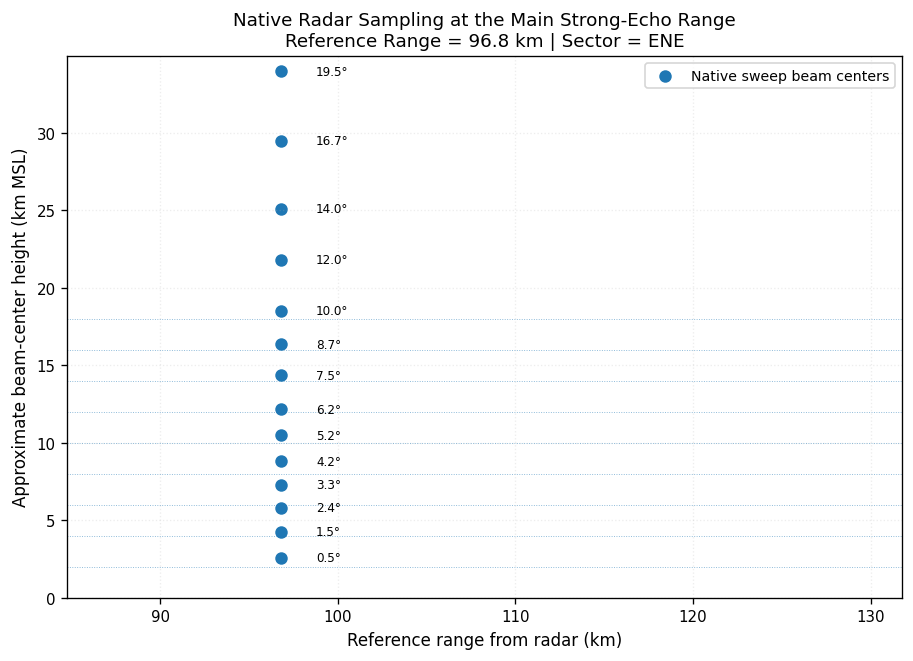

In [16]:
# CELL 16 — Beam-sampling figure at the strong-echo reference range

fig = plt.figure(
    figsize=(
        7.5,
        5.4,
    )
)

ax = fig.add_subplot(
    111
)

ax.scatter(
    np.full(
        len(
            beam_heights
        ),
        MEDIAN_CORE_RANGE_KM,
    ),
    beam_heights,
    s=42,
    label="Native sweep beam centers",
)

for elevation, height in zip(
    beam_elevations,
    beam_heights,
):
    ax.text(
        MEDIAN_CORE_RANGE_KM
        + 2.0,
        height,
        f"{elevation:.1f}°",
        fontsize=7.2,
        va="center",
    )

for target_height in (
    CAPPI_LEVELS_MSL_KM
):
    ax.axhline(
        target_height,
        linewidth=0.55,
        linestyle=":",
        alpha=0.55,
    )

ax.set_xlim(
    MEDIAN_CORE_RANGE_KM
    - 12.0,
    MEDIAN_CORE_RANGE_KM
    + 35.0,
)

ax.set_ylim(
    0.0,
    max(
        GRID_Z_MAX_MSL_KM
        + 2.0,
        np.nanmax(
            beam_heights
        )
        + 1.0,
    ),
)

ax.set_xlabel(
    "Reference range from radar (km)"
)

ax.set_ylabel(
    "Approximate beam-center height (km MSL)"
)

ax.set_title(
    (
        "Native Radar Sampling at the Main Strong-Echo Range\n"
        f"Reference Range = {MEDIAN_CORE_RANGE_KM:.1f} km | "
        f"Sector = {DOMINANT_CORE_SECTOR}"
    )
)

ax.grid(
    alpha=0.22,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "03_fig01_native_beam_sampling_at_core_range.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="native beam sampling",
    processing=(
        "4/3-Earth-radius beam-center approximation."
    ),
    units="km MSL",
    time_UTC=str(
        utc_time
    ),
)

plt.show()

# 11. จาก polar observations ไปเป็น Cartesian grid

Radar gate เดิมมีตำแหน่งตาม:

```text
range
azimuth
elevation
```

เมื่อ gridding จะถูก interpolate ไปยัง:

```text
x
y
z
```

โดย grid point แต่ละจุดอาจได้รับอิทธิพลจาก radar gates หลาย gate ตาม:

- ระยะห่าง
- Radius of Influence
- weighting function
- scan geometry
- beam broadening

ดังนั้น Cartesian pixel/voxel ไม่ใช่ gate เดิมของเรดาร์

# 12. Grid spacing ไม่เท่ากับ radar observational resolution

ข้อมูลนี้มี gate spacing ประมาณ 500 m ตามแนวลำคลื่น

แต่ cross-beam spacing เพิ่มตาม range:

\[
\Delta s \approx r\Delta\theta
\]

และ vertical beam spacing ที่ storm core ก็มีระยะห่างมากกว่า 0.5 km หลายระดับ

ดังนั้น:

```text
0.5-km Cartesian grid
≠
0.5-km independent observations
```

Grid ที่ละเอียดขึ้นช่วยให้ representation smooth/ละเอียดขึ้น แต่ไม่ได้สร้าง measurement ใหม่

In [17]:
# CELL 17 — Native polar sampling summary

gate_spacing_m = float(
    np.nanmedian(
        np.diff(
            radar.range[
                "data"
            ]
        )
    )
)

lowest_sweep_start = int(
    radar.sweep_start_ray_index[
        "data"
    ][0]
)

lowest_sweep_end = int(
    radar.sweep_end_ray_index[
        "data"
    ][0]
)

lowest_azimuth = np.asarray(
    radar.azimuth[
        "data"
    ][
        lowest_sweep_start:
        lowest_sweep_end
        + 1
    ],
    dtype=float,
)

azimuth_sorted = np.sort(
    lowest_azimuth
)

azimuth_diff = np.diff(
    np.r_[
        azimuth_sorted,
        azimuth_sorted[
            0
        ]
        + 360.0,
    ]
)

median_azimuth_spacing_deg = float(
    np.nanmedian(
        azimuth_diff
    )
)

median_azimuth_spacing_rad = (
    np.deg2rad(
        median_azimuth_spacing_deg
    )
)

sampling_rows = []

for range_km in [
    50.0,
    100.0,
    150.0,
    200.0,
]:
    cross_beam_spacing_km = (
        range_km
        * median_azimuth_spacing_rad
    )

    sampling_rows.append({
        "range_km": (
            range_km
        ),
        "along_beam_gate_spacing_km": (
            gate_spacing_m
            / 1000.0
        ),
        "median_azimuth_spacing_deg": (
            median_azimuth_spacing_deg
        ),
        "approx_cross_beam_spacing_km": (
            cross_beam_spacing_km
        ),
    })


polar_sampling_table = pd.DataFrame(
    sampling_rows
)

display(
    polar_sampling_table
)

POLAR_SAMPLING_CSV = (
    OUTPUT_CSV_DIR
    / "03_polar_sampling_geometry.csv"
)

polar_sampling_table.to_csv(
    POLAR_SAMPLING_CSV,
    index=False,
)

,range_km,along_beam_gate_spacing_km,median_azimuth_spacing_deg,approx_cross_beam_spacing_km
0,50.0,0.5,1.0625,0.927206
1,100.0,0.5,1.0625,1.854412
2,150.0,0.5,1.0625,2.781618
3,200.0,0.5,1.0625,3.708825


# 13. Vertical reference: MSL, ARL และ AGL

Notebook นี้กำหนด:

```text
grid_origin_alt = 0 m
```

ดังนั้นค่า `grid.z` จะตีความเป็น **height MSL**

นี่สำคัญมากเพราะ:

- radar altitude = ประมาณ 1.173 km MSL
- CAPPI levels กำหนดเป็น MSL
- thermal levels ใน hail analysis ภายหลังจะอ้างอิง MSL เช่นกัน

> **AGL**
>
> ยังไม่ใช้เป็น vertical coordinate หลัก เพราะต้องมี DEM เพื่อทราบ local terrain height ในแต่ละตำแหน่ง

In [18]:
# CELL 18 — Grid geometry helper

def count_axis_points(
    minimum,
    maximum,
    spacing,
):
    return int(
        round(
            (
                maximum
                - minimum
            )
            / spacing
        )
        + 1
    )


FULL_NX = count_axis_points(
    -FULL_HALF_WIDTH_KM,
    FULL_HALF_WIDTH_KM,
    FULL_DX_KM,
)

FULL_NY = count_axis_points(
    -FULL_HALF_WIDTH_KM,
    FULL_HALF_WIDTH_KM,
    FULL_DY_KM,
)

FULL_NZ = count_axis_points(
    GRID_Z_MIN_MSL_KM,
    GRID_Z_MAX_MSL_KM,
    GRID_DZ_KM,
)


FULL_GRID_SHAPE = (
    FULL_NZ,
    FULL_NY,
    FULL_NX,
)

FULL_GRID_LIMITS = (
    (
        GRID_Z_MIN_MSL_KM
        * 1000.0,
        GRID_Z_MAX_MSL_KM
        * 1000.0,
    ),
    (
        -FULL_HALF_WIDTH_KM
        * 1000.0,
        FULL_HALF_WIDTH_KM
        * 1000.0,
    ),
    (
        -FULL_HALF_WIDTH_KM
        * 1000.0,
        FULL_HALF_WIDTH_KM
        * 1000.0,
    ),
)


full_voxels = int(
    FULL_NZ
    * FULL_NY
    * FULL_NX
)

grid_design = pd.DataFrame({
    "parameter": [
        "full_grid_nz",
        "full_grid_ny",
        "full_grid_nx",
        "full_grid_voxels",
        "full_grid_dx_km",
        "full_grid_dy_km",
        "grid_dz_km",
        "grid_z_min_km_MSL",
        "grid_z_max_km_MSL",
        "full_grid_half_width_km",
    ],
    "value": [
        FULL_NZ,
        FULL_NY,
        FULL_NX,
        full_voxels,
        FULL_DX_KM,
        FULL_DY_KM,
        GRID_DZ_KM,
        GRID_Z_MIN_MSL_KM,
        GRID_Z_MAX_MSL_KM,
        FULL_HALF_WIDTH_KM,
    ],
})

display(
    grid_design
)

print(
    "Approximate single float32 field payload:",
    f"{full_voxels * 4 / 1024**2:.1f} MB",
)

,parameter,value
0,full_grid_nz,38.0
1,full_grid_ny,441.0
2,full_grid_nx,441.0
3,full_grid_voxels,7390278.0
4,full_grid_dx_km,1.0
5,full_grid_dy_km,1.0
6,grid_dz_km,0.5
7,grid_z_min_km_MSL,1.5
8,grid_z_max_km_MSL,20.0
9,full_grid_half_width_km,220.0


Approximate single float32 field payload: 28.2 MB


# 14. Radius of Influence และ weighting

Py-ART `grid_from_radars()` ใช้ gates รอบ grid point ตาม ROI

Notebook นี้ใช้:

```text
gridding_algo      = map_gates_to_grid
weighting_function = Barnes2
roi_func           = dist_beam
min_radius         = 500 m
```

`dist_beam` ทำให้ ROI เปลี่ยนตาม range/beam geometry มากกว่าการใช้ ROI คงที่

> **RESEARCH NOTE**
>
> ROI และ weighting เป็น methodological choices  
> ผลของ maximum ZH, echo shape และ valid support สามารถเปลี่ยนตาม parameter เหล่านี้ได้

In [19]:
# CELL 19 — GateFilter for gridding

def make_reflectivity_gatefilter(
    radar_object,
):
    gatefilter = (
        pyart.filters.GateFilter(
            radar_object
        )
    )

    gatefilter.exclude_invalid(
        FIELD_Z
    )

    gatefilter.exclude_masked(
        FIELD_Z
    )

    try:
        gatefilter.exclude_transition()
    except Exception:
        pass

    return gatefilter


reflectivity_gatefilter = (
    make_reflectivity_gatefilter(
        radar
    )
)

print(
    "Reflectivity gate filter ready."
)

Reflectivity gate filter ready.


In [20]:
# CELL 20 — Reusable 3-D gridding function

def build_3d_reflectivity_grid(
    radar_object,
    *,
    grid_shape,
    grid_limits,
    min_radius_m=MIN_RADIUS_M,
    weighting_function=WEIGHTING_FUNCTION,
    roi_function=ROI_FUNCTION,
    grid_origin=None,
    grid_origin_alt_m=0.0,
    field_name=FIELD_Z,
):
    if grid_origin is None:
        grid_origin = (
            float(
                radar_object.latitude[
                    "data"
                ][0]
            ),
            float(
                radar_object.longitude[
                    "data"
                ][0]
            ),
        )

    gatefilter = (
        make_reflectivity_gatefilter(
            radar_object
        )
    )

    start = time.perf_counter()

    grid_object = (
        pyart.map.grid_from_radars(
            (
                radar_object,
            ),
            grid_shape=(
                grid_shape
            ),
            grid_limits=(
                grid_limits
            ),
            grid_origin=(
                grid_origin
            ),
            grid_origin_alt=(
                grid_origin_alt_m
            ),
            fields=[
                field_name
            ],
            gatefilters=(
                gatefilter
            ),
            gridding_algo=(
                "map_gates_to_grid"
            ),
            weighting_function=(
                weighting_function
            ),
            roi_func=(
                roi_function
            ),
            min_radius=(
                min_radius_m
            ),
            nb=(
                ROI_NB
            ),
            bsp=(
                ROI_BSP
            ),
            h_factor=(
                ROI_H_FACTOR
            ),
            map_roi=False,
        )
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    return (
        grid_object,
        elapsed,
    )

# 15. สร้าง full-domain 3-D Cartesian grid

Full-domain grid ใช้:

```text
±220 km
1-km horizontal spacing
1.5–20 km MSL
0.5-km vertical spacing
```

เป้าหมายคือรักษาบริบททั้ง radar domain และ storm environment

หลังสร้าง grid จะตรวจทันทีว่า:

- grid shape ตรงกับที่กำหนด
- z coordinate เป็น MSL
- field มี valid voxels
- memory/processing time อยู่ในระดับที่เหมาะกับ Colab

In [21]:
# CELL 21 — Build full-domain 3-D grid

print(
    "Building full-domain 3-D Cartesian grid ..."
)

full_grid, full_grid_elapsed_s = (
    build_3d_reflectivity_grid(
        radar,
        grid_shape=(
            FULL_GRID_SHAPE
        ),
        grid_limits=(
            FULL_GRID_LIMITS
        ),
        min_radius_m=(
            MIN_RADIUS_M
        ),
    )
)

print(
    "Completed in:",
    f"{full_grid_elapsed_s:.1f} s",
)

print(
    "Field shape:",
    full_grid.fields[
        FIELD_Z
    ][
        "data"
    ].shape,
)

print(
    "Origin altitude:",
    float(
        full_grid.origin_altitude[
            "data"
        ][0]
    ),
    "m",
)

Building full-domain 3-D Cartesian grid ...
Completed in: 1.2 s
Field shape: (38, 441, 441)
Origin altitude: 0.0 m


In [22]:
# CELL 22 — Inspect full Grid object

full_z_km = (
    np.asarray(
        full_grid.z[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

full_x_km = (
    np.asarray(
        full_grid.x[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

full_y_km = (
    np.asarray(
        full_grid.y[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

full_grid_structure = pd.DataFrame({
    "property": [
        "field",
        "shape",
        "z_min_km_MSL",
        "z_max_km_MSL",
        "z_spacing_km",
        "x_min_km",
        "x_max_km",
        "x_spacing_km",
        "y_min_km",
        "y_max_km",
        "y_spacing_km",
        "origin_latitude_deg",
        "origin_longitude_deg",
        "origin_altitude_m_MSL",
        "projection",
    ],
    "value": [
        FIELD_Z,
        str(
            full_grid.fields[
                FIELD_Z
            ][
                "data"
            ].shape
        ),
        float(
            full_z_km.min()
        ),
        float(
            full_z_km.max()
        ),
        float(
            np.nanmedian(
                np.diff(
                    full_z_km
                )
            )
        ),
        float(
            full_x_km.min()
        ),
        float(
            full_x_km.max()
        ),
        float(
            np.nanmedian(
                np.diff(
                    full_x_km
                )
            )
        ),
        float(
            full_y_km.min()
        ),
        float(
            full_y_km.max()
        ),
        float(
            np.nanmedian(
                np.diff(
                    full_y_km
                )
            )
        ),
        float(
            full_grid.origin_latitude[
                "data"
            ][0]
        ),
        float(
            full_grid.origin_longitude[
                "data"
            ][0]
        ),
        float(
            full_grid.origin_altitude[
                "data"
            ][0]
        ),
        str(
            full_grid.get_projparams()
        ),
    ],
})

display(
    full_grid_structure
)

,property,value
0,field,corrected_reflectivity
1,shape,"(38, 441, 441)"
2,z_min_km_MSL,1.5
3,z_max_km_MSL,20.0
4,z_spacing_km,0.5
5,x_min_km,-220.0
6,x_max_km,220.0
7,x_spacing_km,1.0
8,y_min_km,-220.0
9,y_max_km,220.0


# 16. Vertical data-support diagnostic

CAPPI ระดับหนึ่งจะมีความน่าเชื่อถือเพียงใดขึ้นกับว่า radar volume มี sampling สนับสนุนบริเวณนั้นมากน้อยเพียงใด

Notebook นี้จึงคำนวณในแต่ละระดับ:

- valid voxel fraction — ทั้ง full domain
- valid fraction ภายใน storm ROI
- maximum corrected ZH
- P95 ZH
- Cartesian area ≥ 40/50/55/60 dBZ

เมื่ออยู่บน Cartesian grid แล้ว area สามารถประมาณได้เป็น:

\[
A=N_{pixels}\Delta x\Delta y
\]

ต่างจาก Notebook 02 ที่ยังใช้ polar gate counts และไม่เรียกเป็น area

In [23]:
# CELL 23 — Storm ROI bounds from Notebook 02

roi_xmin_km = float(
    storm_roi_lookup[
        "xmin_km"
    ]
)

roi_xmax_km = float(
    storm_roi_lookup[
        "xmax_km"
    ]
)

roi_ymin_km = float(
    storm_roi_lookup[
        "ymin_km"
    ]
)

roi_ymax_km = float(
    storm_roi_lookup[
        "ymax_km"
    ]
)

print(
    "Notebook-02 storm ROI:"
)

print(
    f"x = {roi_xmin_km:.1f} to "
    f"{roi_xmax_km:.1f} km"
)

print(
    f"y = {roi_ymin_km:.1f} to "
    f"{roi_ymax_km:.1f} km"
)

Notebook-02 storm ROI:
x = -10.3 to 179.6 km
y = -42.2 to 101.5 km


In [24]:
# CELL 24 — Full-grid vertical support and Cartesian echo area

full_field = np.ma.asarray(
    full_grid.fields[
        FIELD_Z
    ][
        "data"
    ]
)

x_roi_mask = (
    (
        full_x_km
        >= roi_xmin_km
    )
    & (
        full_x_km
        <= roi_xmax_km
    )
)

y_roi_mask = (
    (
        full_y_km
        >= roi_ymin_km
    )
    & (
        full_y_km
        <= roi_ymax_km
    )
)

full_pixel_area_km2 = (
    FULL_DX_KM
    * FULL_DY_KM
)

vertical_rows = []

for level_index, height_km in enumerate(
    full_z_km
):
    layer = np.ma.asarray(
        full_field[
            level_index
        ]
    )

    values = layer.filled(
        np.nan
    )

    valid = (
        ~np.ma.getmaskarray(
            layer
        )
        & np.isfinite(
            values
        )
    )

    roi_valid = valid[
        np.ix_(
            y_roi_mask,
            x_roi_mask,
        )
    ]

    roi_values = values[
        np.ix_(
            y_roi_mask,
            x_roi_mask,
        )
    ]

    valid_values = values[
        valid
    ]

    row = {
        "height_km_MSL": float(
            height_km
        ),
        "full_domain_valid_fraction": float(
            valid.mean()
        ),
        "storm_ROI_valid_fraction": (
            float(
                roi_valid.mean()
            )
            if roi_valid.size
            else np.nan
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P95_ZH_dBZ": (
            float(
                np.nanpercentile(
                    valid_values,
                    95,
                )
            )
            if valid_values.size
            else np.nan
        ),
    }

    for threshold in (
        CORE_THRESHOLDS_DBZ
    ):
        row[
            f"area_ZH_ge_{int(threshold)}_km2"
        ] = float(
            (
                valid
                & (
                    values
                    >= threshold
                )
            ).sum()
            * full_pixel_area_km2
        )

        row[
            f"storm_ROI_area_ZH_ge_{int(threshold)}_km2"
        ] = float(
            (
                roi_valid
                & (
                    roi_values
                    >= threshold
                )
            ).sum()
            * full_pixel_area_km2
        )

    vertical_rows.append(
        row
    )


vertical_support = pd.DataFrame(
    vertical_rows
)

display(
    vertical_support
)

VERTICAL_SUPPORT_CSV = (
    OUTPUT_CSV_DIR
    / "03_peak_grid_vertical_support.csv"
)

vertical_support.to_csv(
    VERTICAL_SUPPORT_CSV,
    index=False,
)

,height_km_MSL,full_domain_valid_fraction,storm_ROI_valid_fraction,max_ZH_dBZ,P95_ZH_dBZ,area_ZH_ge_40_km2,storm_ROI_area_ZH_ge_40_km2,area_ZH_ge_50_km2,storm_ROI_area_ZH_ge_50_km2,area_ZH_ge_55_km2,storm_ROI_area_ZH_ge_55_km2,area_ZH_ge_60_km2,storm_ROI_area_ZH_ge_60_km2
0,1.5,0.047886,0.298319,67.071190,44.975185,870.0,861.0,219.0,219.0,60.0,60.0,22.0,22.0
1,2.0,0.063651,0.353034,65.983719,43.660612,1002.0,965.0,242.0,233.0,69.0,69.0,27.0,27.0
2,2.5,0.078769,0.349598,65.698112,42.516691,1052.0,984.0,231.0,222.0,63.0,63.0,25.0,25.0
3,3.0,0.087304,0.367836,65.513451,41.884033,1070.0,1002.0,217.0,210.0,67.0,67.0,23.0,23.0
4,3.5,0.092539,0.392032,65.517601,41.362836,1082.0,1015.0,203.0,197.0,63.0,63.0,22.0,22.0
5,4.0,0.095454,0.403143,65.471008,40.483108,985.0,922.0,179.0,174.0,59.0,59.0,22.0,22.0
6,4.5,0.095264,0.396747,65.450005,39.815649,898.0,836.0,162.0,157.0,54.0,54.0,22.0,22.0
7,5.0,0.094822,0.390205,65.192223,39.052406,802.0,743.0,146.0,141.0,52.0,52.0,22.0,22.0
8,5.5,0.093860,0.380190,64.702522,38.490873,751.0,692.0,139.0,134.0,53.0,53.0,22.0,22.0
9,6.0,0.093942,0.374963,64.081779,37.691931,670.0,614.0,122.0,117.0,52.0,52.0,22.0,22.0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_fig02_vertical_data_support.png


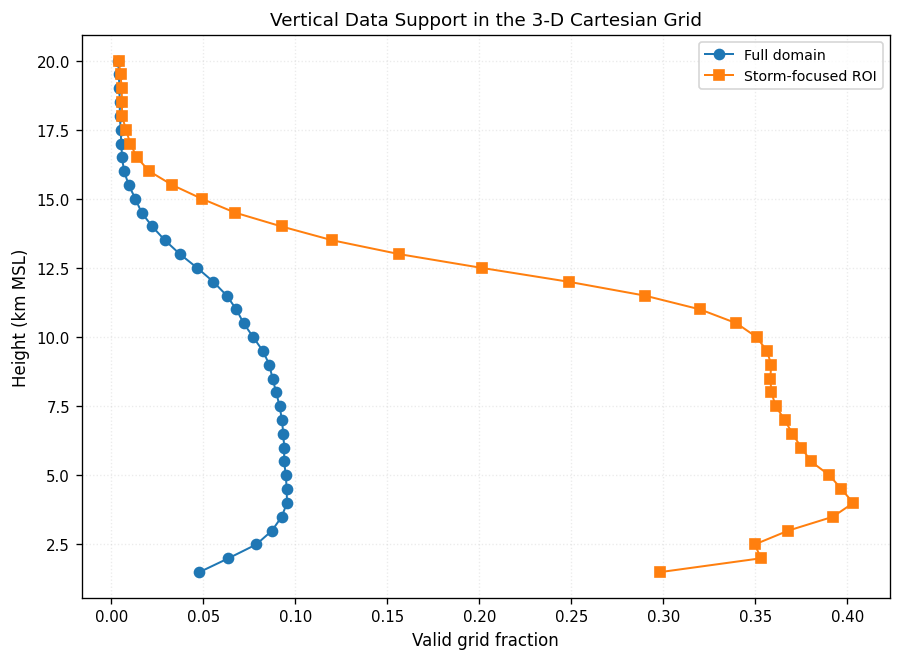

In [25]:
# CELL 25 — Vertical-support figure

fig = plt.figure(
    figsize=(
        7.4,
        5.4,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    vertical_support[
        "full_domain_valid_fraction"
    ],
    vertical_support[
        "height_km_MSL"
    ],
    marker="o",
    label="Full domain",
)

ax.plot(
    vertical_support[
        "storm_ROI_valid_fraction"
    ],
    vertical_support[
        "height_km_MSL"
    ],
    marker="s",
    label="Storm-focused ROI",
)

ax.set_xlabel(
    "Valid grid fraction"
)

ax.set_ylabel(
    "Height (km MSL)"
)

ax.set_title(
    "Vertical Data Support in the 3-D Cartesian Grid"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "03_fig02_vertical_data_support.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="vertical data support",
    processing=(
        "Valid-grid fraction by constant MSL level."
    ),
    units="fraction",
    time_UTC=str(
        utc_time
    ),
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_fig03_strong_echo_area_vs_height.png


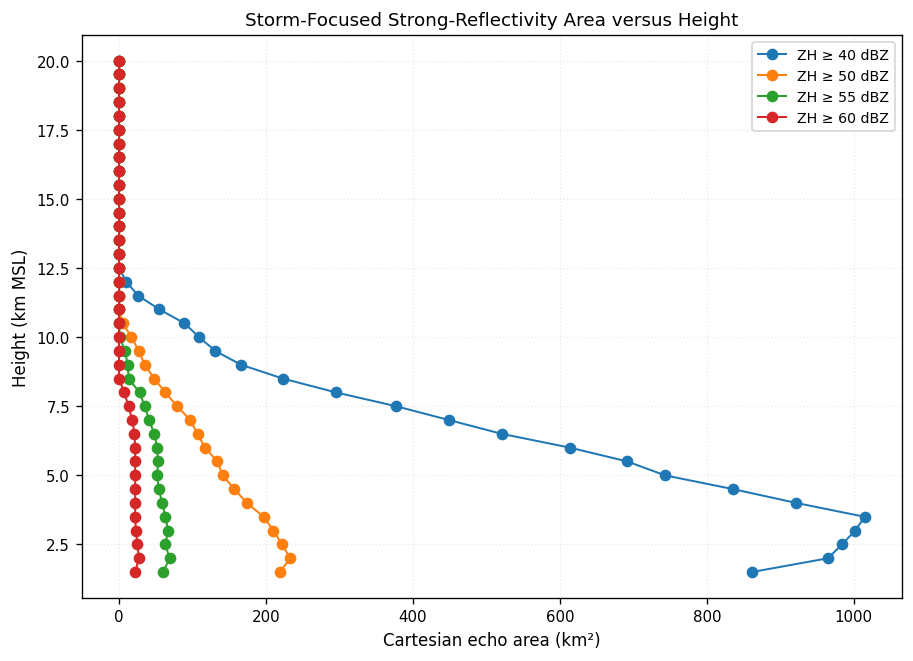

In [26]:
# CELL 26 — Strong-echo area versus height

fig = plt.figure(
    figsize=(
        7.5,
        5.4,
    )
)

ax = fig.add_subplot(
    111
)

for threshold in (
    CORE_THRESHOLDS_DBZ
):
    ax.plot(
        vertical_support[
            f"storm_ROI_area_ZH_ge_{int(threshold)}_km2"
        ],
        vertical_support[
            "height_km_MSL"
        ],
        marker="o",
        label=(
            f"ZH ≥ {threshold:.0f} dBZ"
        ),
    )

ax.set_xlabel(
    "Cartesian echo area (km²)"
)

ax.set_ylabel(
    "Height (km MSL)"
)

ax.set_title(
    "Storm-Focused Strong-Reflectivity Area versus Height"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "03_fig03_strong_echo_area_vs_height.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="strong echo area versus height",
    processing=(
        "Area calculated on 1-km Cartesian grid; "
        "not an echo-top retrieval."
    ),
    units="km2",
    time_UTC=str(
        utc_time
    ),
)

plt.show()

# 17. CAPPI — Constant Altitude Plan Position Indicator

CAPPI คือ field บนระดับความสูงคงที่ใน Cartesian grid

Notebook นี้ใช้ระดับ:

```text
2, 4, 6, 8, 10, 12, 14, 16, 18 km MSL
```

CAPPI ทุกระดับ:

- ใช้ corrected reflectivity
- ใช้ color scale เดียวกัน
- ใช้ domain เดียวกันเมื่อเปรียบเทียบ
- ตรวจ vertical support ก่อนตีความ

> **RESEARCH NOTE**
>
> CAPPI 2 km MSL ที่ storm range ประมาณ 97 km อาจอยู่ต่ำกว่า lowest native beam center  
> ดังนั้น CAPPI ระดับนี้เป็น interpolated representation ที่ต้องตีความร่วมกับ sampling geometry

In [27]:
# CELL 27 — CAPPI extractor

def extract_cappi(
    grid_object,
    field_name,
    target_height_msl_km,
):
    z_km = (
        np.asarray(
            grid_object.z[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    level_index = int(
        np.argmin(
            np.abs(
                z_km
                - target_height_msl_km
            )
        )
    )

    actual_height = float(
        z_km[
            level_index
        ]
    )

    data = np.ma.asarray(
        grid_object.fields[
            field_name
        ][
            "data"
        ][
            level_index
        ]
    )

    return {
        "level_index": (
            level_index
        ),
        "requested_height_km_MSL": (
            float(
                target_height_msl_km
            )
        ),
        "actual_height_km_MSL": (
            actual_height
        ),
        "height_error_km": (
            actual_height
            - float(
                target_height_msl_km
            )
        ),
        "data": data,
    }

In [28]:
# CELL 28 — CAPPI level summary

cappi_rows = []

for target_height in (
    CAPPI_LEVELS_MSL_KM
):
    cappi = extract_cappi(
        full_grid,
        FIELD_Z,
        target_height,
    )

    data = np.ma.asarray(
        cappi[
            "data"
        ]
    )

    values = data.filled(
        np.nan
    )

    valid = (
        ~np.ma.getmaskarray(
            data
        )
        & np.isfinite(
            values
        )
    )

    valid_values = values[
        valid
    ]

    sampling_row = (
        cappi_sampling_table.loc[
            np.isclose(
                cappi_sampling_table[
                    "requested_CAPPI_km_MSL"
                ],
                target_height,
            )
        ].iloc[0]
    )

    row = {
        "requested_height_km_MSL": (
            target_height
        ),
        "actual_height_km_MSL": (
            cappi[
                "actual_height_km_MSL"
            ]
        ),
        "valid_fraction": float(
            valid.mean()
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P95_ZH_dBZ": (
            float(
                np.nanpercentile(
                    valid_values,
                    95,
                )
            )
            if valid_values.size
            else np.nan
        ),
        "nearest_native_elevation_deg": float(
            sampling_row[
                "nearest_native_elevation_deg"
            ]
        ),
        "nearest_beam_center_km_MSL": float(
            sampling_row[
                "nearest_beam_center_km_MSL"
            ]
        ),
        "absolute_vertical_mismatch_km": float(
            sampling_row[
                "absolute_vertical_mismatch_km"
            ]
        ),
    }

    for threshold in (
        CORE_THRESHOLDS_DBZ
    ):
        row[
            f"area_ZH_ge_{int(threshold)}_km2"
        ] = float(
            (
                valid
                & (
                    values
                    >= threshold
                )
            ).sum()
            * full_pixel_area_km2
        )

    cappi_rows.append(
        row
    )


cappi_level_summary = pd.DataFrame(
    cappi_rows
)

display(
    cappi_level_summary
)

CAPPI_LEVEL_CSV = (
    OUTPUT_CSV_DIR
    / "03_CAPPI_level_summary.csv"
)

cappi_level_summary.to_csv(
    CAPPI_LEVEL_CSV,
    index=False,
)

,requested_height_km_MSL,actual_height_km_MSL,valid_fraction,max_ZH_dBZ,P95_ZH_dBZ,nearest_native_elevation_deg,nearest_beam_center_km_MSL,absolute_vertical_mismatch_km,area_ZH_ge_40_km2,area_ZH_ge_50_km2,area_ZH_ge_55_km2,area_ZH_ge_60_km2
0,2.0,2.0,0.063651,65.983719,43.660612,0.500000,2.568526,0.568526,1002.0,242.0,69.0,27.0
1,4.0,4.0,0.095454,65.471008,40.483108,1.500000,4.256739,0.256739,985.0,179.0,59.0,22.0
2,6.0,6.0,0.093942,64.081779,37.691931,2.406250,5.785740,0.214260,670.0,122.0,52.0,22.0
3,8.0,8.0,0.089603,61.470932,33.493488,3.296875,7.287124,0.712876,337.0,63.0,28.0,7.0
4,10.0,10.0,0.077051,55.879383,28.163753,5.203125,10.494744,0.494744,133.0,17.0,1.0,0.0
5,12.0,12.0,0.055424,41.434605,21.926505,6.203125,12.173292,0.173292,10.0,0.0,0.0,0.0
6,14.0,14.0,0.022203,32.134773,20.066330,7.500000,14.344853,0.344853,0.0,0.0,0.0,0.0
7,16.0,16.0,0.006885,31.325146,17.326732,8.703125,16.353187,0.353187,0.0,0.0,0.0,0.0
8,18.0,18.0,0.004628,18.391464,17.527892,10.000000,18.510242,0.510242,0.0,0.0,0.0,0.0


# 18. เตรียม geographic domain และ plotting helpers

Full-domain map จะมี:

- ADM1
- ADM2
- radar location
- range rings 50/100/150/200 km
- strong-echo reference point

Storm-focused maps จะ **ไม่ใช้ range-ring labels** เพื่อไม่ให้ label ไปทับ title หรือออกนอกกรอบแบบที่พบใน Notebook 02

ทุก figure ใช้ scientific display names เช่น:

```text
Corrected Reflectivity
```

ไม่แสดง internal field name เช่น:

```text
corrected_reflectivity
```

In [29]:
# CELL 29 — Full-grid geographic coordinates and clipped GIS

full_lon, full_lat = (
    full_grid.get_point_longitude_latitude(
        level=0
    )
)

lon_min = float(
    np.nanmin(
        full_lon
    )
)

lon_max = float(
    np.nanmax(
        full_lon
    )
)

lat_min = float(
    np.nanmin(
        full_lat
    )
)

lat_max = float(
    np.nanmax(
        full_lat
    )
)

adm1_clip = adm1.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

adm2_clip = adm2.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

print(
    "ADM1 in full grid domain:",
    len(
        adm1_clip
    ),
)

print(
    "ADM2 in full grid domain:",
    len(
        adm2_clip
    ),
)

ADM1 in full grid domain: 15
ADM2 in full grid domain: 149


In [30]:
# CELL 30 — Geodesic range-ring helper

GEOD = Geod(
    ellps="WGS84"
)


def geodesic_range_ring(
    radar_lon,
    radar_lat,
    radius_km,
    n_points=361,
):
    azimuths = np.linspace(
        0.0,
        360.0,
        n_points,
    )

    lons = np.empty_like(
        azimuths
    )

    lats = np.empty_like(
        azimuths
    )

    distance_m = (
        radius_km
        * 1000.0
    )

    for index, azimuth in enumerate(
        azimuths
    ):
        lon_i, lat_i, _ = (
            GEOD.fwd(
                radar_lon,
                radar_lat,
                azimuth,
                distance_m,
            )
        )

        lons[
            index
        ] = lon_i

        lats[
            index
        ] = lat_i

    return (
        lons,
        lats,
    )


def strong_core_reference_lonlat():
    core_x_m = (
        MEDIAN_CORE_RANGE_KM
        * 1000.0
        * np.sin(
            np.deg2rad(
                MEDIAN_CORE_AZIMUTH_DEG
            )
        )
    )

    core_y_m = (
        MEDIAN_CORE_RANGE_KM
        * 1000.0
        * np.cos(
            np.deg2rad(
                MEDIAN_CORE_AZIMUTH_DEG
            )
        )
    )

    lon, lat = (
        pyart.core.cartesian_to_geographic_aeqd(
            np.array(
                [
                    core_x_m
                ]
            ),
            np.array(
                [
                    core_y_m
                ]
            ),
            radar_lon,
            radar_lat,
        )
    )

    return (
        float(
            lon[
                0
            ]
        ),
        float(
            lat[
                0
            ]
        ),
    )


CORE_REF_LON, CORE_REF_LAT = (
    strong_core_reference_lonlat()
)

print(
    "Strong-echo reference lon/lat:",
    CORE_REF_LON,
    CORE_REF_LAT,
)

Strong-echo reference lon/lat: 99.31371291095486 18.030633492917154


In [31]:
# CELL 31 — Full-domain geographic CAPPI plotting helper

def plot_full_domain_cappi(
    grid_object,
    *,
    target_height_km,
    output_path,
):
    cappi = extract_cappi(
        grid_object,
        FIELD_Z,
        target_height_km,
    )

    data = np.ma.asarray(
        cappi[
            "data"
        ]
    )

    lon, lat = (
        grid_object.get_point_longitude_latitude(
            level=(
                cappi[
                    "level_index"
                ]
            )
        )
    )

    projection = (
        ccrs.PlateCarree()
    )

    fig = plt.figure(
        figsize=(
            8.4,
            7.4,
        )
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            float(
                np.nanmin(
                    lon
                )
            ),
            float(
                np.nanmax(
                    lon
                )
            ),
            float(
                np.nanmin(
                    lat
                )
            ),
            float(
                np.nanmax(
                    lat
                )
            ),
        ],
        crs=projection,
    )

    mesh = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=projection,
        shading="auto",
        cmap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        rasterized=True,
        zorder=1,
    )

    for geom in (
        adm2_clip.geometry
    ):
        ax.add_geometries(
            [
                geom
            ],
            crs=projection,
            facecolor="none",
            edgecolor="0.76",
            linewidth=0.18,
            zorder=2,
        )

    for geom in (
        adm1_clip.geometry
    ):
        ax.add_geometries(
            [
                geom
            ],
            crs=projection,
            facecolor="none",
            edgecolor="0.24",
            linewidth=0.55,
            zorder=3,
        )

    for radius_km in [
        50,
        100,
        150,
        200,
    ]:
        ring_lon, ring_lat = (
            geodesic_range_ring(
                radar_lon,
                radar_lat,
                radius_km,
            )
        )

        ax.plot(
            ring_lon,
            ring_lat,
            transform=projection,
            linewidth=0.45,
            linestyle=":",
            alpha=0.58,
            zorder=4,
        )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=42,
        label="Omkoi radar",
        zorder=5,
    )

    ax.scatter(
        CORE_REF_LON,
        CORE_REF_LAT,
        transform=projection,
        marker="o",
        s=28,
        label="Strong-echo reference",
        zorder=6,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.40,
        alpha=0.30,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.88,
    )

    cbar.set_label(
        "Corrected reflectivity (dBZ)"
    )

    ax.set_title(
        (
            "Omkoi S-band Radar — Corrected-Reflectivity CAPPI\n"
            f"Observed-Hail Event | "
            f"{cappi['actual_height_km_MSL']:.1f} km MSL | "
            f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
        ),
        pad=10,
    )

    ax.legend(
        loc="upper right",
        frameon=True,
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        product="full-domain CAPPI",
        height_km_MSL=(
            cappi[
                "actual_height_km_MSL"
            ]
        ),
        field=FIELD_Z,
        processing=(
            "1-km full-domain Cartesian grid; Barnes2 + dist_beam."
        ),
        units="dBZ",
        time_UTC=str(
            utc_time
        ),
        colormap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_full_CAPPI_ZH_2.0kmMSL.png


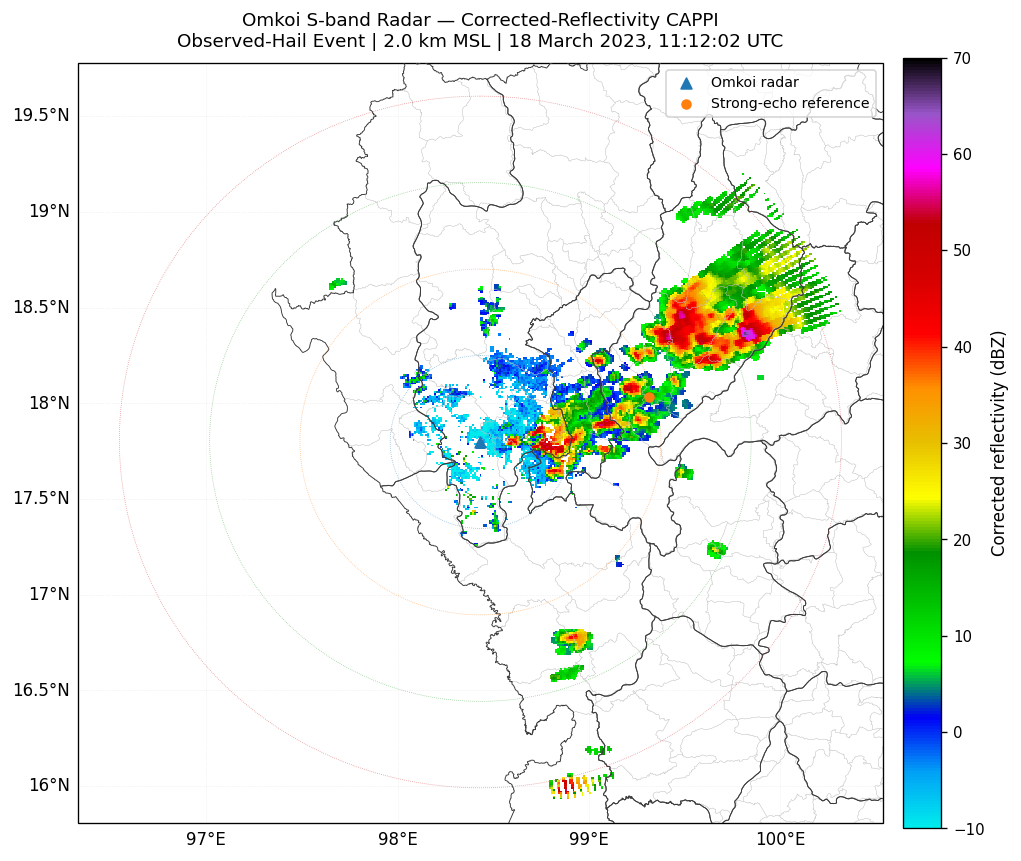

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_full_CAPPI_ZH_6.0kmMSL.png


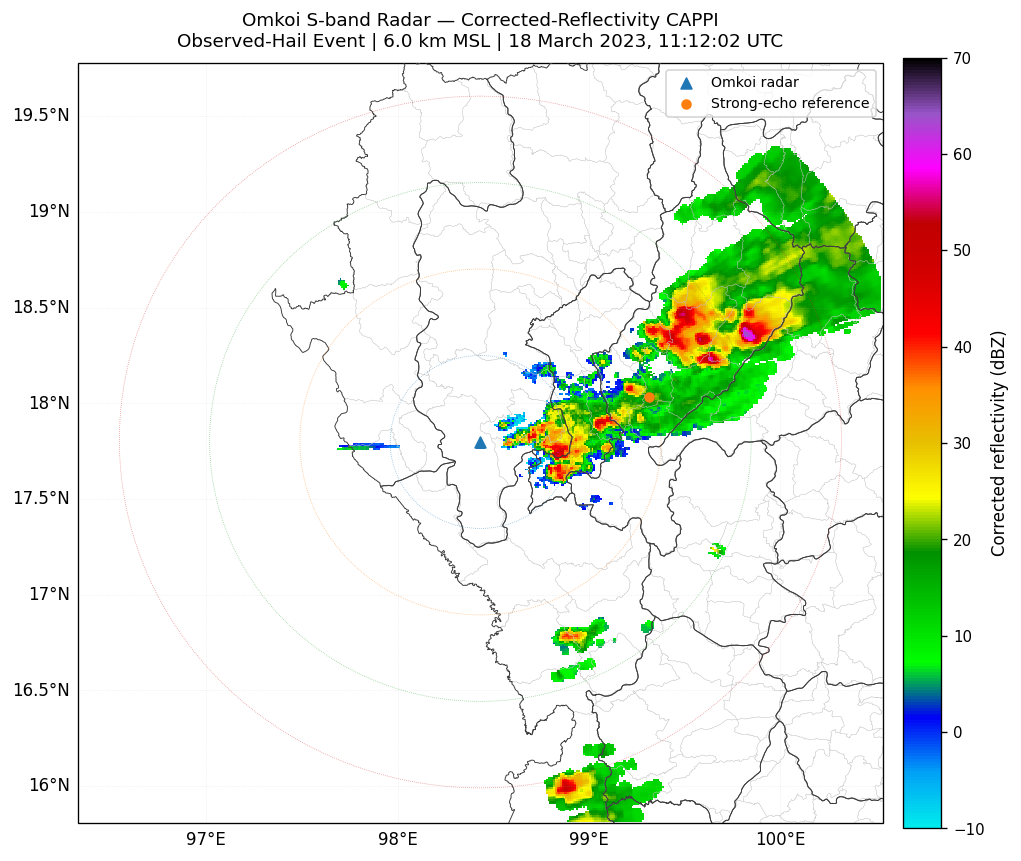

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_full_CAPPI_ZH_10.0kmMSL.png


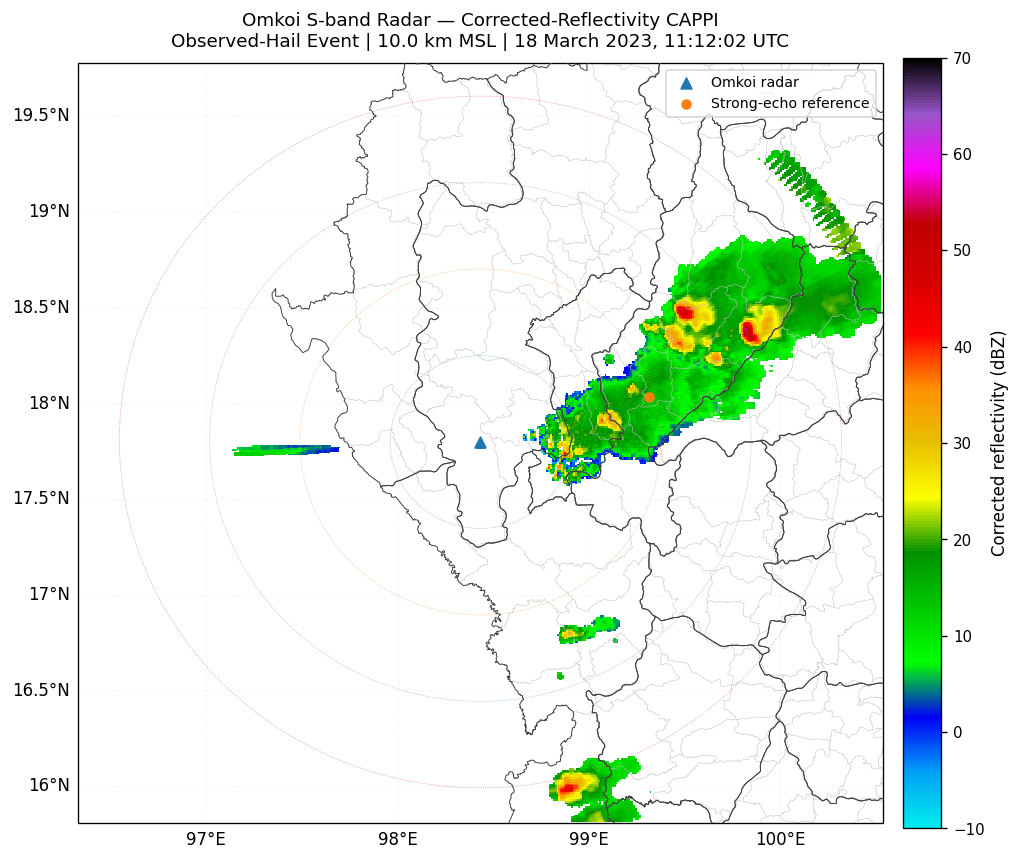

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_full_CAPPI_ZH_14.0kmMSL.png


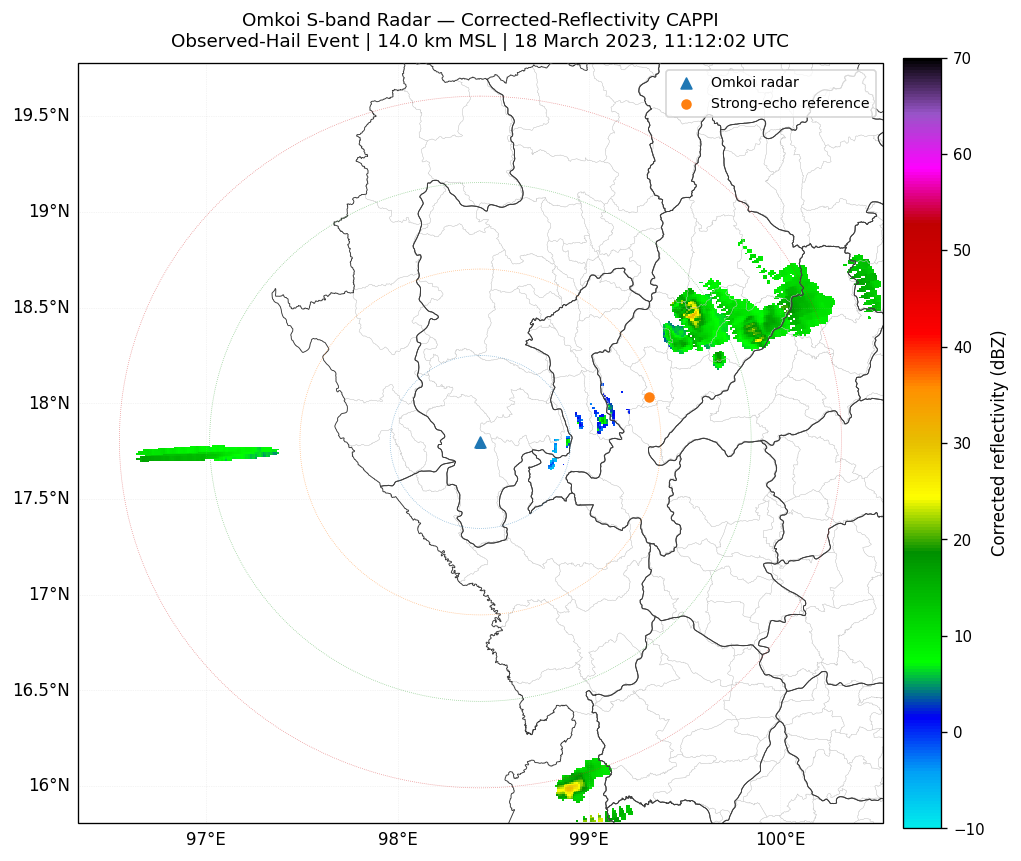

In [32]:
# CELL 32 — Export selected full-domain CAPPI figures

FULL_CAPPI_FIGURES = []

for target_height in (
    PRIMARY_CAPPI_LEVELS_MSL_KM
):
    output_path = (
        FIGURE_DIR
        / (
            "03_full_CAPPI_ZH_"
            f"{target_height:.1f}kmMSL.png"
        )
    )

    plot_full_domain_cappi(
        full_grid,
        target_height_km=(
            target_height
        ),
        output_path=(
            output_path
        ),
    )

    FULL_CAPPI_FIGURES.append(
        output_path
    )

# 19. CAPPI gallery แบบ storm-focused

เพื่อดู vertical evolution ของ hail-producing convective complex จะสร้าง storm-focused CAPPI ทุกระดับ 2–18 km MSL

Figure จะใช้:

- domain เดียวกัน
- color scale เดียวกัน
- 40/50/55/60-dBZ contours
- ไม่มี range-ring labels
- title และ colorbar เป็นภาษาอังกฤษ

In [33]:
# CELL 33 — Storm-focused CAPPI plotting helper from full grid

def plot_storm_focused_cappi(
    grid_object,
    *,
    target_height_km,
    output_path,
):
    cappi = extract_cappi(
        grid_object,
        FIELD_Z,
        target_height_km,
    )

    layer = np.ma.asarray(
        cappi[
            "data"
        ]
    )

    values = layer.filled(
        np.nan
    )

    x_km = (
        np.asarray(
            grid_object.x[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    y_km = (
        np.asarray(
            grid_object.y[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    x_mask = (
        (
            x_km
            >= roi_xmin_km
        )
        & (
            x_km
            <= roi_xmax_km
        )
    )

    y_mask = (
        (
            y_km
            >= roi_ymin_km
        )
        & (
            y_km
            <= roi_ymax_km
        )
    )

    x_sub = x_km[
        x_mask
    ]

    y_sub = y_km[
        y_mask
    ]

    layer_sub = layer[
        np.ix_(
            y_mask,
            x_mask,
        )
    ]

    values_sub = values[
        np.ix_(
            y_mask,
            x_mask,
        )
    ]

    fig = plt.figure(
        figsize=(
            7.8,
            6.6,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        x_sub,
        y_sub,
        layer_sub,
        shading="auto",
        cmap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.90,
    )

    cbar.set_label(
        "Corrected reflectivity (dBZ)"
    )

    finite_values = values_sub[
        np.isfinite(
            values_sub
        )
    ]

    if finite_values.size:
        usable_levels = [
            threshold
            for threshold in (
                CORE_THRESHOLDS_DBZ
            )
            if (
                np.nanmin(
                    finite_values
                )
                <= threshold
                <= np.nanmax(
                    finite_values
                )
            )
        ]

        if usable_levels:
            contours = ax.contour(
                x_sub,
                y_sub,
                values_sub,
                levels=(
                    usable_levels
                ),
                linewidths=1.0,
                zorder=4,
            )

            ax.clabel(
                contours,
                fmt=lambda value: (
                    f"{value:.0f} dBZ"
                ),
                fontsize=7,
                inline=True,
            )

    ax.scatter(
        0,
        0,
        marker="^",
        s=32,
        label="Omkoi radar",
        zorder=5,
    )

    core_x = (
        MEDIAN_CORE_RANGE_KM
        * np.sin(
            np.deg2rad(
                MEDIAN_CORE_AZIMUTH_DEG
            )
        )
    )

    core_y = (
        MEDIAN_CORE_RANGE_KM
        * np.cos(
            np.deg2rad(
                MEDIAN_CORE_AZIMUTH_DEG
            )
        )
    )

    ax.scatter(
        core_x,
        core_y,
        marker="o",
        s=28,
        label="Strong-echo reference",
        zorder=6,
    )

    ax.set_xlim(
        roi_xmin_km,
        roi_xmax_km,
    )

    ax.set_ylim(
        roi_ymin_km,
        roi_ymax_km,
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_title(
        (
            "Observed-Hail Event — Storm-Focused CAPPI\n"
            f"Corrected Reflectivity | "
            f"{cappi['actual_height_km_MSL']:.1f} km MSL | "
            f"{utc_time.strftime('%H:%M:%S UTC')}"
        ),
        pad=10,
    )

    ax.grid(
        alpha=0.16,
        linestyle=":",
    )

    ax.legend(
        loc="best",
        frameon=True,
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        product="storm-focused CAPPI",
        height_km_MSL=(
            cappi[
                "actual_height_km_MSL"
            ]
        ),
        field=FIELD_Z,
        processing=(
            "Storm-focused subset of 1-km full-domain grid; "
            "40/50/55/60-dBZ contours."
        ),
        units="dBZ",
        time_UTC=str(
            utc_time
        ),
        colormap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_2.0kmMSL.png


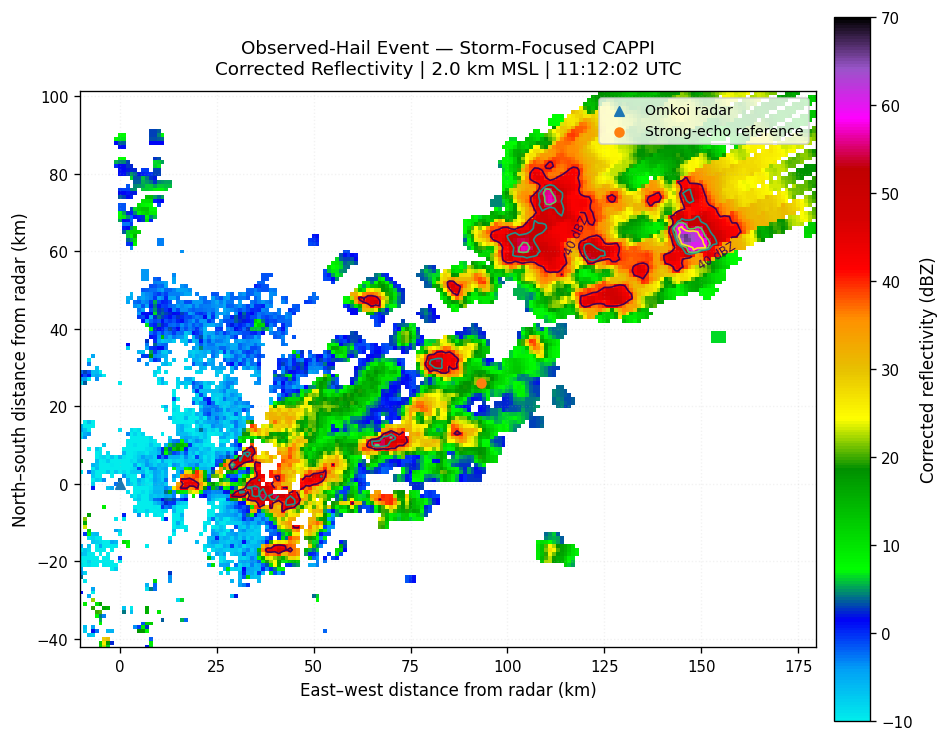

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_4.0kmMSL.png


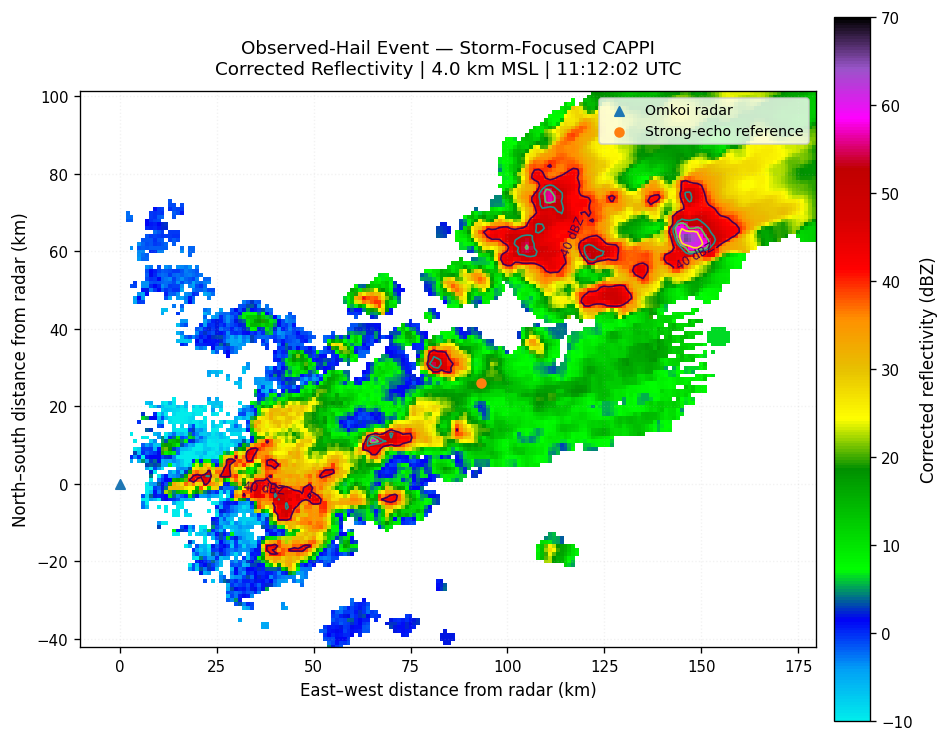

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_6.0kmMSL.png


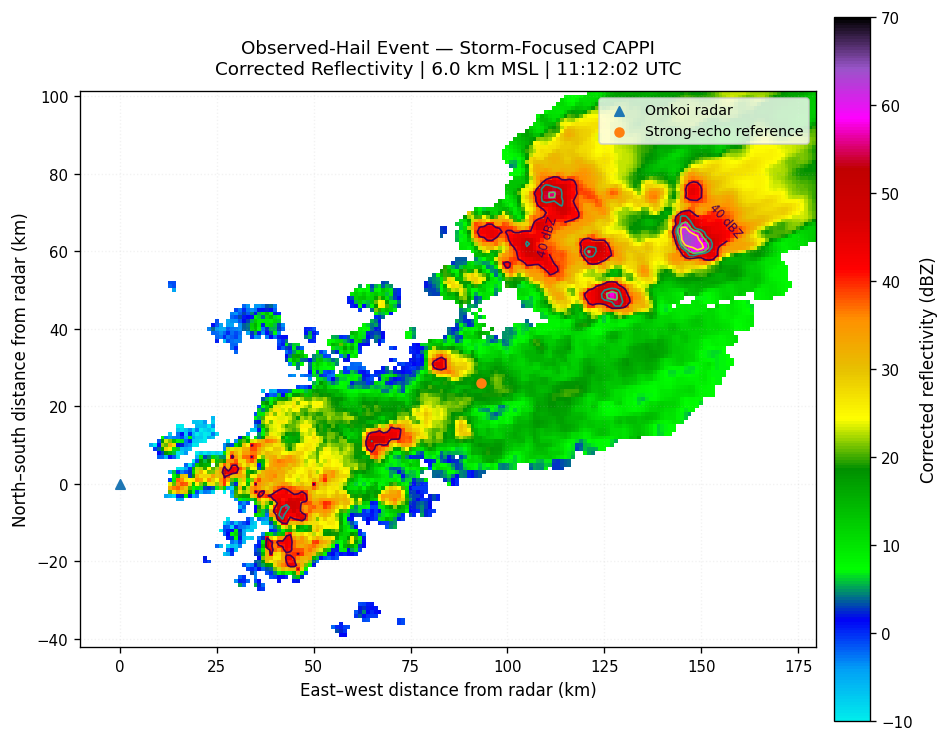

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_8.0kmMSL.png


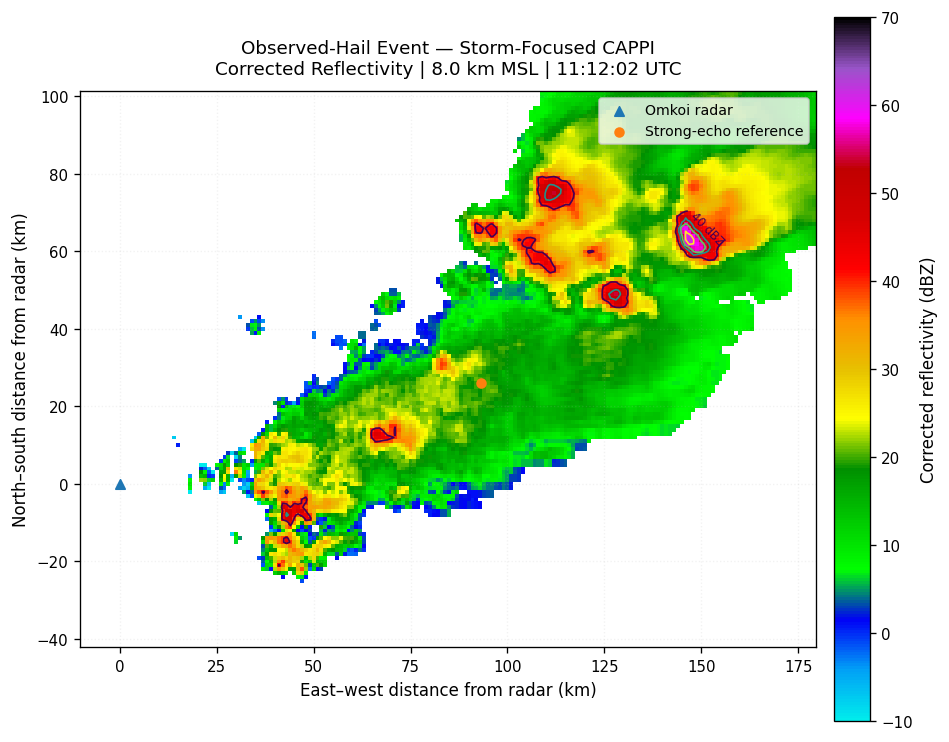

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_10.0kmMSL.png


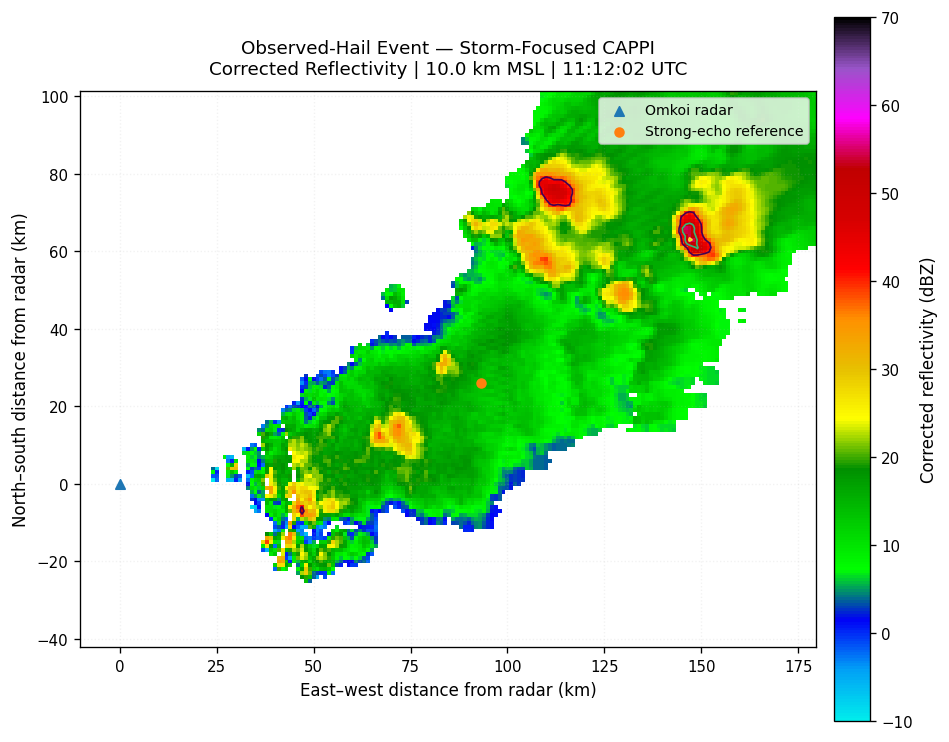

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_12.0kmMSL.png


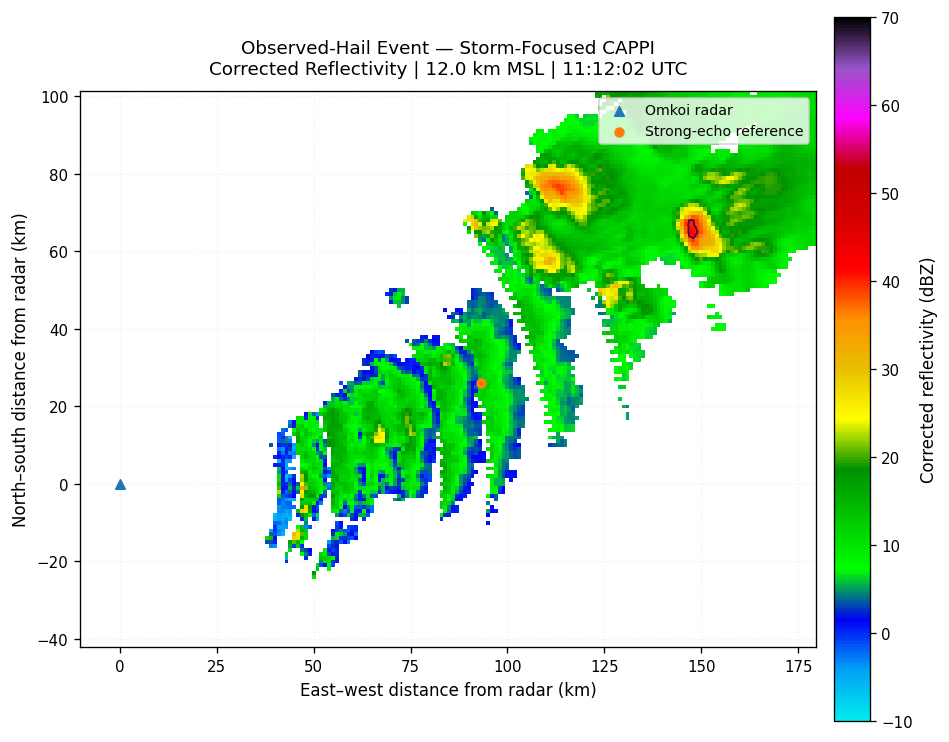

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_14.0kmMSL.png


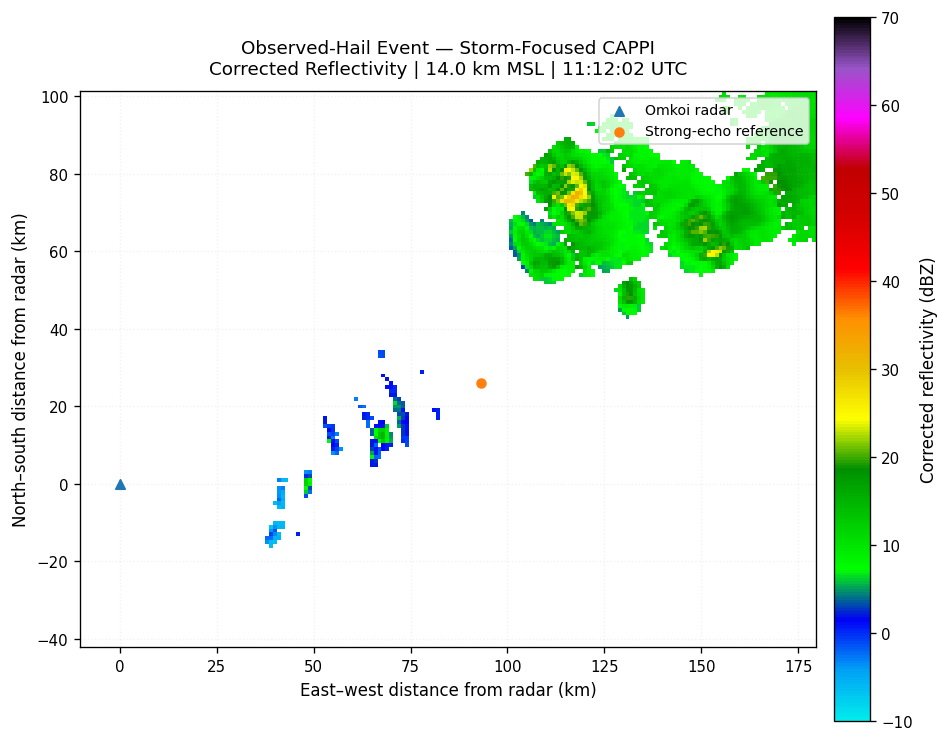

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_16.0kmMSL.png


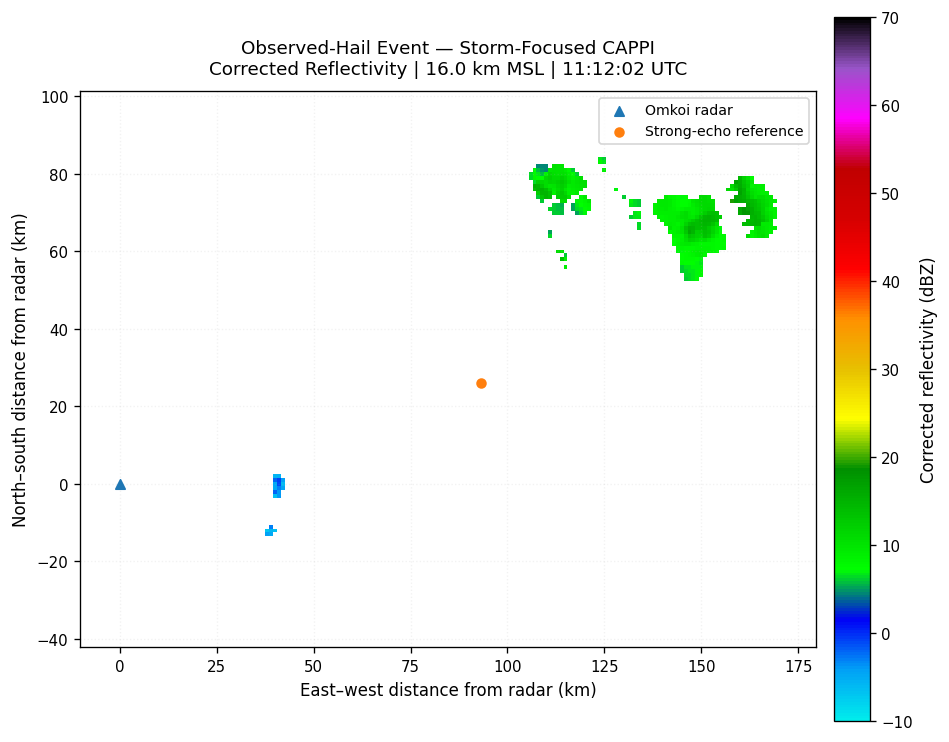

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_storm_CAPPI_ZH_18.0kmMSL.png


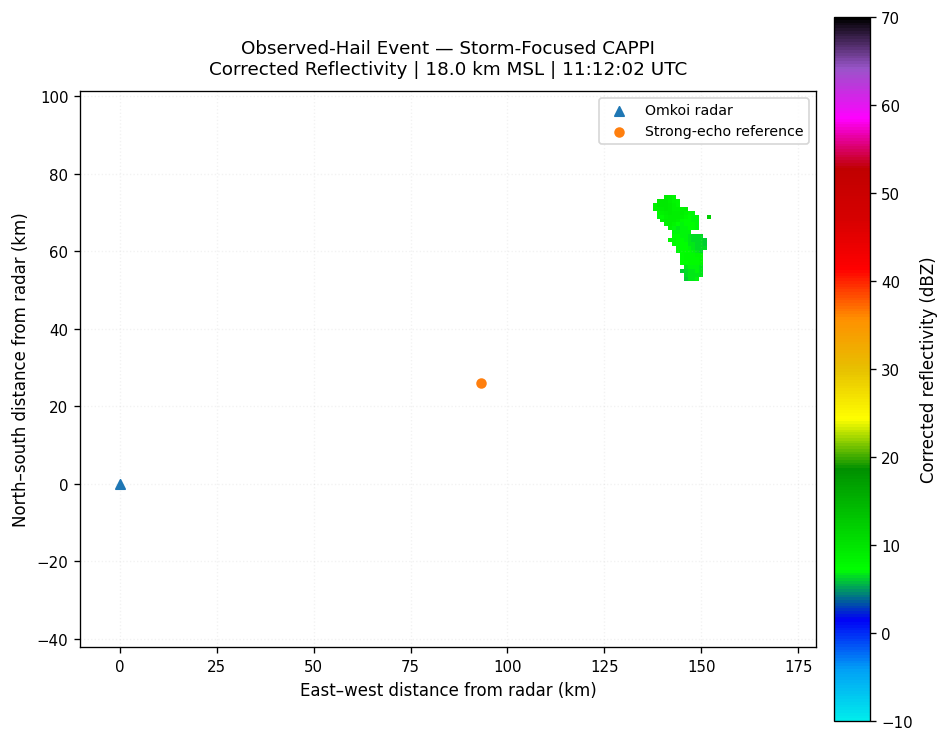

In [34]:
# CELL 34 — Export storm-focused CAPPI gallery

STORM_CAPPI_FIGURES = []

for target_height in (
    CAPPI_LEVELS_MSL_KM
):
    output_path = (
        FIGURE_DIR
        / (
            "03_storm_CAPPI_ZH_"
            f"{target_height:.1f}kmMSL.png"
        )
    )

    plot_storm_focused_cappi(
        full_grid,
        target_height_km=(
            target_height
        ),
        output_path=(
            output_path
        ),
    )

    STORM_CAPPI_FIGURES.append(
        output_path
    )

# 20. Column-maximum reflectivity — introductory 3-D projection

สำหรับแต่ละ x-y column:

\[
Z_{max}(x,y)
=
\max_z Z(x,y,z)
\]

Column maximum ช่วยดูตำแหน่ง intense core ที่อาจอยู่เหนือ lowest sweep

แต่:

```text
Column maximum ≠ CAPPI
Column maximum ≠ echo top
Column maximum ≠ hail probability
```

เป็นเพียง projection ของ maximum reflectivity ใน vertical column

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_fig04_column_max_reflectivity.png


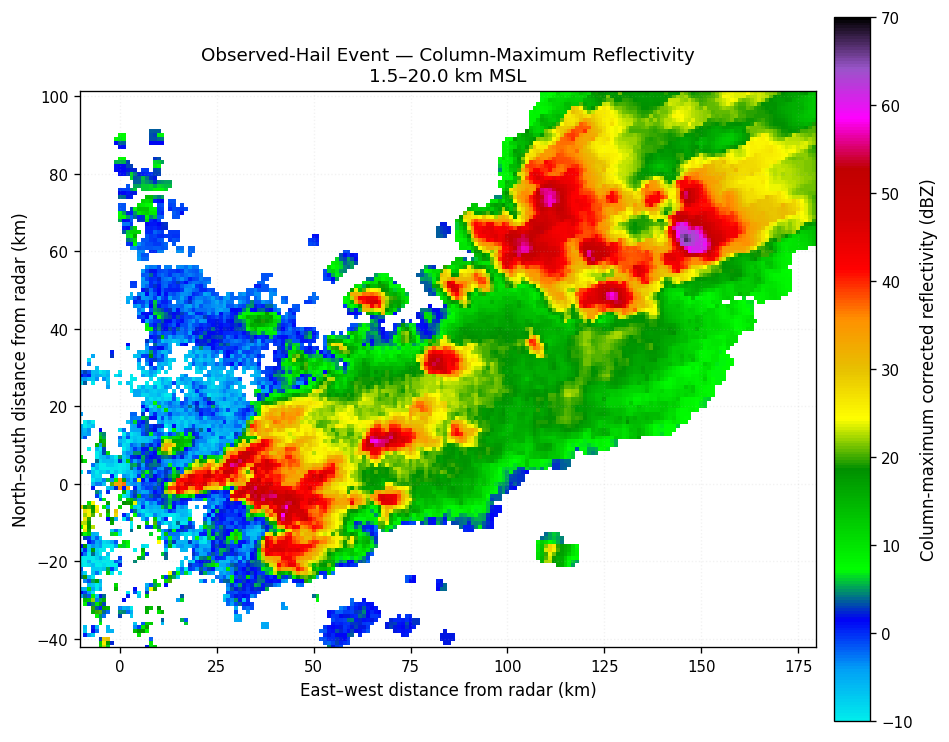

In [35]:
# CELL 35 — Column maximum reflectivity

full_field_values = (
    full_field.filled(
        np.nan
    )
)

column_max = np.nanmax(
    full_field_values,
    axis=0,
)

column_valid = np.any(
    np.isfinite(
        full_field_values
    ),
    axis=0,
)

column_max = np.ma.array(
    column_max,
    mask=(
        ~column_valid
    ),
)

fig = plt.figure(
    figsize=(
        7.8,
        6.6,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    full_x_km,
    full_y_km,
    column_max,
    shading="auto",
    cmap=CMAP_Z,
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.90,
)

cbar.set_label(
    "Column-maximum corrected reflectivity (dBZ)"
)

ax.set_xlim(
    roi_xmin_km,
    roi_xmax_km,
)

ax.set_ylim(
    roi_ymin_km,
    roi_ymax_km,
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    (
        "Observed-Hail Event — Column-Maximum Reflectivity\n"
        f"{GRID_Z_MIN_MSL_KM:.1f}–"
        f"{GRID_Z_MAX_MSL_KM:.1f} km MSL"
    )
)

ax.grid(
    alpha=0.16,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "03_fig04_column_max_reflectivity.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="column maximum reflectivity",
    field=FIELD_Z,
    processing=(
        "Maximum corrected reflectivity through "
        "the 1.5–20 km MSL Cartesian column."
    ),
    units="dBZ",
    time_UTC=str(
        utc_time
    ),
    colormap=CMAP_Z,
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
)

plt.show()

# 21. สร้าง storm-focused high-resolution 3-D grid

Full-domain grid 1 km เหมาะกับ spatial context และ GIS

แต่ hail-producing convective complex สามารถวิเคราะห์ใน local domain ที่ละเอียดขึ้นได้

Notebook นี้อ่าน storm ROI จาก Notebook 02 แล้วเพิ่ม buffer เพื่อสร้าง:

```text
horizontal spacing = 0.5 km
vertical spacing   = 0.5 km
vertical range     = 1.5–20 km MSL
```

> **สำคัญ**
>
> Storm-focused grid ละเอียดขึ้นในเชิง representation  
> แต่ observational sampling ยังคงถูกจำกัดด้วย gate spacing, azimuth spacing, beam width และ elevation geometry เดิม

In [36]:
# CELL 36 — Align storm-focused bounds to 0.5-km grid

def align_down(
    value,
    spacing,
):
    return (
        math.floor(
            value
            / spacing
        )
        * spacing
    )


def align_up(
    value,
    spacing,
):
    return (
        math.ceil(
            value
            / spacing
        )
        * spacing
    )


storm_xmin_km = align_down(
    roi_xmin_km
    - STORM_GRID_BUFFER_KM,
    STORM_DX_KM,
)

storm_xmax_km = align_up(
    roi_xmax_km
    + STORM_GRID_BUFFER_KM,
    STORM_DX_KM,
)

storm_ymin_km = align_down(
    roi_ymin_km
    - STORM_GRID_BUFFER_KM,
    STORM_DY_KM,
)

storm_ymax_km = align_up(
    roi_ymax_km
    + STORM_GRID_BUFFER_KM,
    STORM_DY_KM,
)


STORM_NX = count_axis_points(
    storm_xmin_km,
    storm_xmax_km,
    STORM_DX_KM,
)

STORM_NY = count_axis_points(
    storm_ymin_km,
    storm_ymax_km,
    STORM_DY_KM,
)

STORM_NZ = FULL_NZ


STORM_GRID_SHAPE = (
    STORM_NZ,
    STORM_NY,
    STORM_NX,
)

STORM_GRID_LIMITS = (
    (
        GRID_Z_MIN_MSL_KM
        * 1000.0,
        GRID_Z_MAX_MSL_KM
        * 1000.0,
    ),
    (
        storm_ymin_km
        * 1000.0,
        storm_ymax_km
        * 1000.0,
    ),
    (
        storm_xmin_km
        * 1000.0,
        storm_xmax_km
        * 1000.0,
    ),
)


storm_grid_design = pd.DataFrame({
    "parameter": [
        "storm_xmin_km",
        "storm_xmax_km",
        "storm_ymin_km",
        "storm_ymax_km",
        "storm_nx",
        "storm_ny",
        "storm_nz",
        "storm_dx_km",
        "storm_dy_km",
        "storm_dz_km",
        "storm_voxels",
    ],
    "value": [
        storm_xmin_km,
        storm_xmax_km,
        storm_ymin_km,
        storm_ymax_km,
        STORM_NX,
        STORM_NY,
        STORM_NZ,
        STORM_DX_KM,
        STORM_DY_KM,
        GRID_DZ_KM,
        int(
            STORM_NX
            * STORM_NY
            * STORM_NZ
        ),
    ],
})

display(
    storm_grid_design
)

,parameter,value
0,storm_xmin_km,-20.5
1,storm_xmax_km,190.0
2,storm_ymin_km,-52.5
3,storm_ymax_km,111.5
4,storm_nx,422.0
5,storm_ny,329.0
6,storm_nz,38.0
7,storm_dx_km,0.5
8,storm_dy_km,0.5
9,storm_dz_km,0.5


In [37]:
# CELL 37 — Build storm-focused 0.5-km 3-D grid

print(
    "Building storm-focused 0.5-km 3-D grid ..."
)

storm_grid, storm_grid_elapsed_s = (
    build_3d_reflectivity_grid(
        radar,
        grid_shape=(
            STORM_GRID_SHAPE
        ),
        grid_limits=(
            STORM_GRID_LIMITS
        ),
        min_radius_m=(
            MIN_RADIUS_M
        ),
    )
)

print(
    "Completed in:",
    f"{storm_grid_elapsed_s:.1f} s",
)

print(
    "Storm-grid shape:",
    storm_grid.fields[
        FIELD_Z
    ][
        "data"
    ].shape,
)

Building storm-focused 0.5-km 3-D grid ...
Completed in: 1.3 s
Storm-grid shape: (38, 329, 422)


In [38]:
# CELL 38 — Storm-grid support summary

storm_z_km = (
    np.asarray(
        storm_grid.z[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

storm_x_km = (
    np.asarray(
        storm_grid.x[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

storm_y_km = (
    np.asarray(
        storm_grid.y[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

storm_field = np.ma.asarray(
    storm_grid.fields[
        FIELD_Z
    ][
        "data"
    ]
)

storm_pixel_area_km2 = (
    STORM_DX_KM
    * STORM_DY_KM
)

storm_support_rows = []

for level_index, height_km in enumerate(
    storm_z_km
):
    layer = np.ma.asarray(
        storm_field[
            level_index
        ]
    )

    values = layer.filled(
        np.nan
    )

    valid = (
        ~np.ma.getmaskarray(
            layer
        )
        & np.isfinite(
            values
        )
    )

    valid_values = values[
        valid
    ]

    row = {
        "height_km_MSL": (
            float(
                height_km
            )
        ),
        "valid_fraction": float(
            valid.mean()
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P95_ZH_dBZ": (
            float(
                np.nanpercentile(
                    valid_values,
                    95,
                )
            )
            if valid_values.size
            else np.nan
        ),
    }

    for threshold in (
        CORE_THRESHOLDS_DBZ
    ):
        row[
            f"area_ZH_ge_{int(threshold)}_km2"
        ] = float(
            (
                valid
                & (
                    values
                    >= threshold
                )
            ).sum()
            * storm_pixel_area_km2
        )

    storm_support_rows.append(
        row
    )


storm_grid_support = pd.DataFrame(
    storm_support_rows
)

display(
    storm_grid_support
)

STORM_SUPPORT_CSV = (
    OUTPUT_CSV_DIR
    / "03_storm_focus_grid_vertical_support.csv"
)

storm_grid_support.to_csv(
    STORM_SUPPORT_CSV,
    index=False,
)

,height_km_MSL,valid_fraction,max_ZH_dBZ,P95_ZH_dBZ,area_ZH_ge_40_km2,area_ZH_ge_50_km2,area_ZH_ge_55_km2,area_ZH_ge_60_km2
0,1.5,0.245826,67.324150,45.700104,868.50,215.75,58.50,23.00
1,2.0,0.305716,66.454773,44.536748,964.25,226.50,65.50,25.75
2,2.5,0.308179,65.792236,44.576602,994.25,221.00,63.75,23.50
3,3.0,0.320481,65.609169,44.299223,1006.50,208.50,65.50,22.00
4,3.5,0.338510,65.596573,43.813256,1004.25,199.75,62.25,21.75
5,4.0,0.346641,65.563705,42.886909,924.25,173.75,58.00,21.75
6,4.5,0.342723,65.571785,42.377669,835.00,153.00,52.50,21.75
7,5.0,0.338013,65.419464,41.670886,741.50,139.75,52.00,21.75
8,5.5,0.330788,64.868675,41.468100,691.50,132.25,50.00,20.75
9,6.0,0.326344,64.366623,40.676904,618.00,116.75,49.25,21.25


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_fig05_storm_highres_CAPPI_6km.png


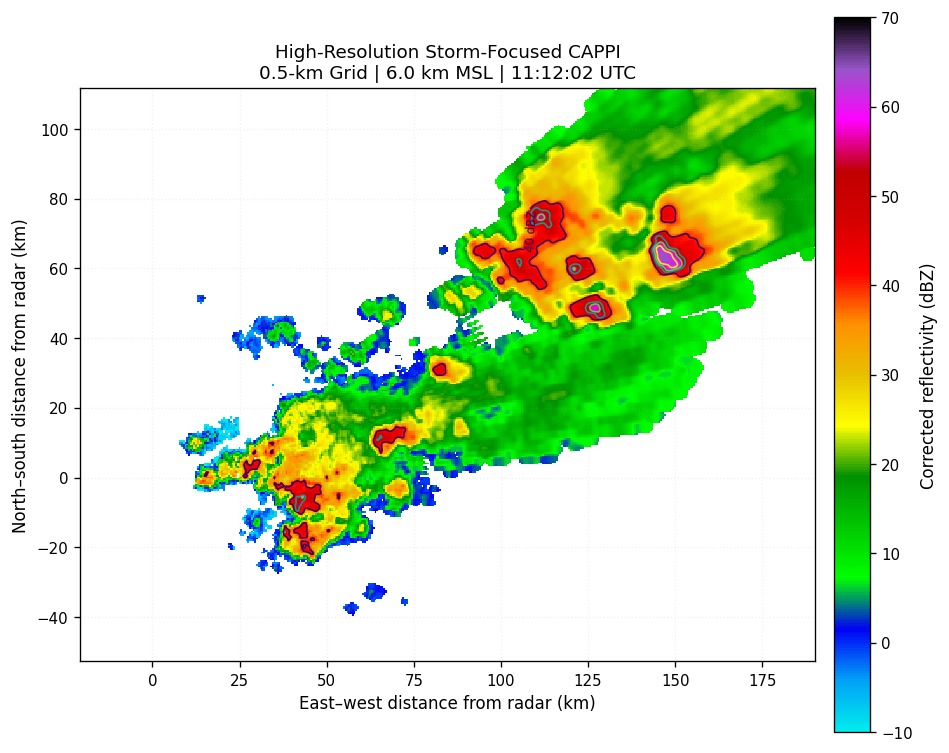

In [39]:
# CELL 39 — Storm-focused high-resolution CAPPI example

storm_cappi = extract_cappi(
    storm_grid,
    FIELD_Z,
    EXPERIMENT_CAPPI_MSL_KM,
)

storm_cappi_data = np.ma.asarray(
    storm_cappi[
        "data"
    ]
)

fig = plt.figure(
    figsize=(
        7.8,
        6.7,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    storm_x_km,
    storm_y_km,
    storm_cappi_data,
    shading="auto",
    cmap=CMAP_Z,
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.90,
)

cbar.set_label(
    "Corrected reflectivity (dBZ)"
)

values = storm_cappi_data.filled(
    np.nan
)

finite_values = values[
    np.isfinite(
        values
    )
]

if finite_values.size:
    usable_levels = [
        threshold
        for threshold in (
            CORE_THRESHOLDS_DBZ
        )
        if (
            np.nanmin(
                finite_values
            )
            <= threshold
            <= np.nanmax(
                finite_values
            )
        )
    ]

    if usable_levels:
        contours = ax.contour(
            storm_x_km,
            storm_y_km,
            values,
            levels=(
                usable_levels
            ),
            linewidths=1.0,
        )

        ax.clabel(
            contours,
            fmt=lambda value: (
                f"{value:.0f} dBZ"
            ),
            fontsize=7,
        )

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    (
        "High-Resolution Storm-Focused CAPPI\n"
        f"0.5-km Grid | "
        f"{storm_cappi['actual_height_km_MSL']:.1f} km MSL | "
        f"{utc_time.strftime('%H:%M:%S UTC')}"
    )
)

ax.grid(
    alpha=0.16,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "03_fig05_storm_highres_CAPPI_6km.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="storm high-resolution CAPPI",
    height_km_MSL=(
        storm_cappi[
            "actual_height_km_MSL"
        ]
    ),
    field=FIELD_Z,
    processing=(
        "0.5-km storm-focused Cartesian grid; "
        "Barnes2 + dist_beam."
    ),
    units="dBZ",
    time_UTC=str(
        utc_time
    ),
    colormap=CMAP_Z,
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
)

plt.show()

# 22. EXPERIMENT — Grid-spacing sensitivity

สร้าง single-level 6-km MSL grid ใน storm-focused domain ที่:

```text
2.0 km
1.0 km
0.5 km
```

แล้วเปรียบเทียบ:

- number of pixels
- processing time
- valid fraction
- maximum ZH
- P95 ZH
- area ≥ 40/50/55/60 dBZ

เป้าหมายไม่ใช่หา grid ที่ “ดีที่สุด” จากตัวเลขเพียงชุดเดียว  
แต่เพื่อให้เห็นว่าผลลัพธ์สามารถเปลี่ยนเมื่อ representation เปลี่ยน

In [40]:
# CELL 40 — Single-level grid helper for sensitivity experiments

def build_single_level_grid(
    radar_object,
    *,
    target_height_km,
    x_min_km,
    x_max_km,
    y_min_km,
    y_max_km,
    spacing_km,
    min_radius_m=MIN_RADIUS_M,
    field_name=FIELD_Z,
):
    nx = count_axis_points(
        x_min_km,
        x_max_km,
        spacing_km,
    )

    ny = count_axis_points(
        y_min_km,
        y_max_km,
        spacing_km,
    )

    grid_shape = (
        1,
        ny,
        nx,
    )

    z_m = (
        target_height_km
        * 1000.0
    )

    grid_limits = (
        (
            z_m,
            z_m,
        ),
        (
            y_min_km
            * 1000.0,
            y_max_km
            * 1000.0,
        ),
        (
            x_min_km
            * 1000.0,
            x_max_km
            * 1000.0,
        ),
    )

    grid_object, elapsed = (
        build_3d_reflectivity_grid(
            radar_object,
            grid_shape=(
                grid_shape
            ),
            grid_limits=(
                grid_limits
            ),
            min_radius_m=(
                min_radius_m
            ),
            field_name=(
                field_name
            ),
        )
    )

    return {
        "grid": (
            grid_object
        ),
        "elapsed_seconds": (
            elapsed
        ),
        "nx": (
            nx
        ),
        "ny": (
            ny
        ),
        "spacing_km": (
            spacing_km
        ),
    }

In [41]:
# CELL 41 — Grid-spacing sensitivity experiment

spacing_rows = []

spacing_grids = {}

for spacing_km in (
    GRID_SPACING_EXPERIMENT_KM
):
    print(
        "Grid spacing:",
        spacing_km,
        "km",
    )

    result = (
        build_single_level_grid(
            radar,
            target_height_km=(
                EXPERIMENT_CAPPI_MSL_KM
            ),
            x_min_km=(
                storm_xmin_km
            ),
            x_max_km=(
                storm_xmax_km
            ),
            y_min_km=(
                storm_ymin_km
            ),
            y_max_km=(
                storm_ymax_km
            ),
            spacing_km=(
                spacing_km
            ),
            min_radius_m=(
                MIN_RADIUS_M
            ),
        )
    )

    grid_i = result[
        "grid"
    ]

    layer = np.ma.asarray(
        grid_i.fields[
            FIELD_Z
        ][
            "data"
        ][0]
    )

    values = layer.filled(
        np.nan
    )

    valid = (
        ~np.ma.getmaskarray(
            layer
        )
        & np.isfinite(
            values
        )
    )

    valid_values = values[
        valid
    ]

    row = {
        "spacing_km": (
            spacing_km
        ),
        "nx": (
            result[
                "nx"
            ]
        ),
        "ny": (
            result[
                "ny"
            ]
        ),
        "pixel_count": int(
            result[
                "nx"
            ]
            * result[
                "ny"
            ]
        ),
        "elapsed_seconds": float(
            result[
                "elapsed_seconds"
            ]
        ),
        "valid_fraction": float(
            valid.mean()
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P95_ZH_dBZ": (
            float(
                np.nanpercentile(
                    valid_values,
                    95,
                )
            )
            if valid_values.size
            else np.nan
        ),
    }

    pixel_area = (
        spacing_km
        * spacing_km
    )

    for threshold in (
        CORE_THRESHOLDS_DBZ
    ):
        row[
            f"area_ZH_ge_{int(threshold)}_km2"
        ] = float(
            (
                valid
                & (
                    values
                    >= threshold
                )
            ).sum()
            * pixel_area
        )

    spacing_rows.append(
        row
    )

    spacing_grids[
        spacing_km
    ] = (
        grid_i
    )


grid_spacing_experiment = (
    pd.DataFrame(
        spacing_rows
    )
)

display(
    grid_spacing_experiment
)

GRID_SPACING_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_resolution_experiment.csv"
)

grid_spacing_experiment.to_csv(
    GRID_SPACING_CSV,
    index=False,
)

Grid spacing: 2.0 km
Grid spacing: 1.0 km
Grid spacing: 0.5 km


,spacing_km,nx,ny,pixel_count,elapsed_seconds,valid_fraction,max_ZH_dBZ,P95_ZH_dBZ,area_ZH_ge_40_km2,area_ZH_ge_50_km2,area_ZH_ge_55_km2,area_ZH_ge_60_km2
0,2.0,106,83,8798,0.551896,0.322119,64.153770,40.759317,620.0,116.00,48.00,24.00
1,1.0,211,165,34815,0.549164,0.325492,64.153770,40.693492,620.0,114.00,49.00,21.00
2,0.5,422,329,138838,0.592299,0.326344,64.366623,40.676904,618.0,116.75,49.25,21.25


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_grid_spacing_2.0km_6.0kmMSL.png


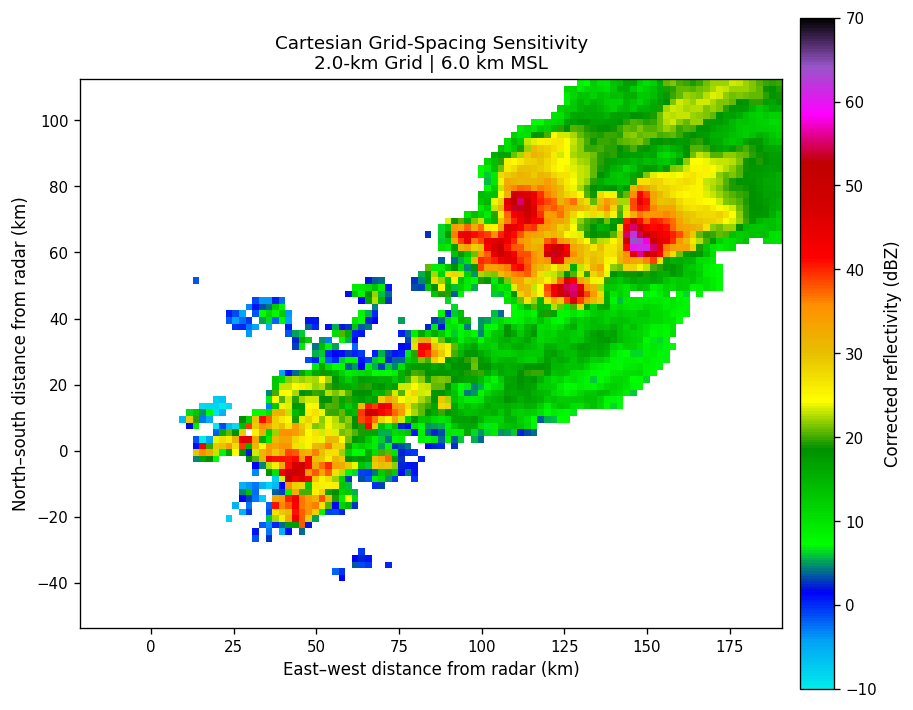

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_grid_spacing_1.0km_6.0kmMSL.png


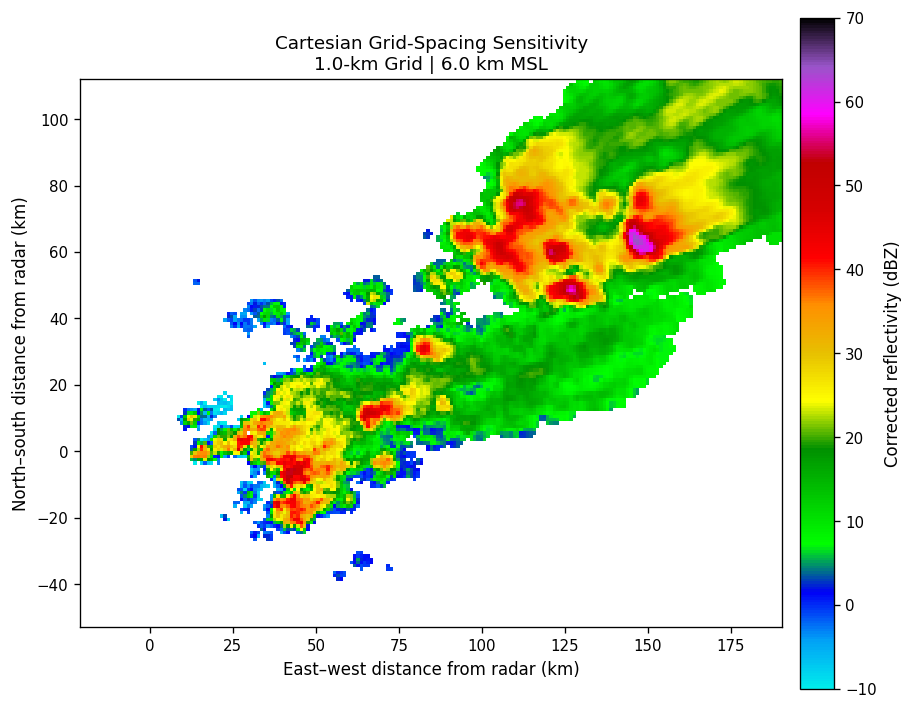

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_grid_spacing_0.5km_6.0kmMSL.png


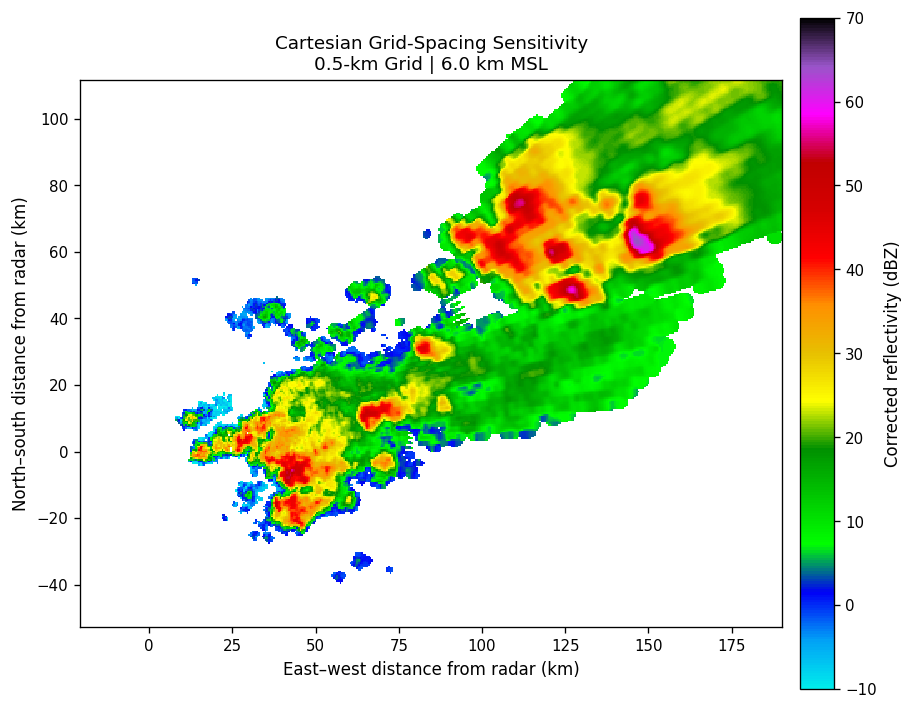

In [42]:
# CELL 42 — Grid-spacing sensitivity figures

for spacing_km, grid_i in (
    spacing_grids.items()
):
    layer = np.ma.asarray(
        grid_i.fields[
            FIELD_Z
        ][
            "data"
        ][0]
    )

    x_km_i = (
        np.asarray(
            grid_i.x[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    y_km_i = (
        np.asarray(
            grid_i.y[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    fig = plt.figure(
        figsize=(
            7.5,
            6.3,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        x_km_i,
        y_km_i,
        layer,
        shading="auto",
        cmap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.90,
    )

    cbar.set_label(
        "Corrected reflectivity (dBZ)"
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_title(
        (
            "Cartesian Grid-Spacing Sensitivity\n"
            f"{spacing_km:.1f}-km Grid | "
            f"{EXPERIMENT_CAPPI_MSL_KM:.1f} km MSL"
        )
    )

    F = (
        FIGURE_DIR
        / (
            "03_grid_spacing_"
            f"{spacing_km:.1f}km_"
            f"{EXPERIMENT_CAPPI_MSL_KM:.1f}kmMSL.png"
        )
    )

    save_figure(
        fig,
        F,
        source_file=selected_filename,
        product="grid spacing sensitivity",
        height_km_MSL=(
            EXPERIMENT_CAPPI_MSL_KM
        ),
        field=FIELD_Z,
        processing=(
            f"Spacing={spacing_km:.1f} km; "
            "same storm-focused domain; Barnes2 + dist_beam."
        ),
        units="dBZ",
        time_UTC=str(
            utc_time
        ),
        colormap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
    )

    plt.show()

# 23. EXPERIMENT — Radius-of-Influence sensitivity

ใช้ storm-focused 1-km CAPPI 6 km MSL แล้วเปลี่ยน minimum ROI:

```text
500 m
1000 m
1500 m
```

ตรวจผลต่อ:

- valid fraction
- maximum ZH
- P95
- strong-echo area

ROI ที่ใหญ่ขึ้นอาจเพิ่ม spatial coverage แต่สามารถ smooth gradients และลด local maxima ได้

In [43]:
# CELL 43 — ROI sensitivity experiment

roi_rows = []

roi_grids = {}

for min_radius_m in (
    ROI_MIN_RADIUS_EXPERIMENT_M
):
    print(
        "Minimum ROI:",
        min_radius_m,
        "m",
    )

    result = (
        build_single_level_grid(
            radar,
            target_height_km=(
                EXPERIMENT_CAPPI_MSL_KM
            ),
            x_min_km=(
                storm_xmin_km
            ),
            x_max_km=(
                storm_xmax_km
            ),
            y_min_km=(
                storm_ymin_km
            ),
            y_max_km=(
                storm_ymax_km
            ),
            spacing_km=(
                1.0
            ),
            min_radius_m=(
                min_radius_m
            ),
        )
    )

    grid_i = result[
        "grid"
    ]

    layer = np.ma.asarray(
        grid_i.fields[
            FIELD_Z
        ][
            "data"
        ][0]
    )

    values = layer.filled(
        np.nan
    )

    valid = (
        ~np.ma.getmaskarray(
            layer
        )
        & np.isfinite(
            values
        )
    )

    valid_values = values[
        valid
    ]

    row = {
        "min_radius_m": (
            min_radius_m
        ),
        "valid_fraction": float(
            valid.mean()
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P95_ZH_dBZ": (
            float(
                np.nanpercentile(
                    valid_values,
                    95,
                )
            )
            if valid_values.size
            else np.nan
        ),
        "elapsed_seconds": float(
            result[
                "elapsed_seconds"
            ]
        ),
    }

    for threshold in (
        CORE_THRESHOLDS_DBZ
    ):
        row[
            f"area_ZH_ge_{int(threshold)}_km2"
        ] = float(
            (
                valid
                & (
                    values
                    >= threshold
                )
            ).sum()
        )

    roi_rows.append(
        row
    )

    roi_grids[
        min_radius_m
    ] = (
        grid_i
    )


roi_sensitivity = pd.DataFrame(
    roi_rows
)

display(
    roi_sensitivity
)

ROI_SENSITIVITY_CSV = (
    OUTPUT_CSV_DIR
    / "03_ROI_sensitivity_experiment.csv"
)

roi_sensitivity.to_csv(
    ROI_SENSITIVITY_CSV,
    index=False,
)

Minimum ROI: 500.0 m
Minimum ROI: 1000.0 m
Minimum ROI: 1500.0 m


,min_radius_m,valid_fraction,max_ZH_dBZ,P95_ZH_dBZ,elapsed_seconds,area_ZH_ge_40_km2,area_ZH_ge_50_km2,area_ZH_ge_55_km2,area_ZH_ge_60_km2
0,500.0,0.325492,64.15377,40.693492,0.556723,620.0,114.0,49.0,21.0
1,1000.0,0.331955,64.15377,40.349606,0.672458,604.0,114.0,49.0,21.0
2,1500.0,0.344995,64.15377,39.844418,0.874841,587.0,112.0,49.0,21.0


# 24. ADVANCED — Interpolation space: dBZ หรือ linear Z?

dBZ เป็น logarithmic quantity:

\[
dBZ=10\log_{10}Z
\]

ดังนั้นการ average/interpolate dBZ โดยตรงไม่เท่ากับ:

```text
dBZ → linear Z
     ↓
interpolate Z
     ↓
Z → dBZ
```

Operational radar workflows มัก grid reflectivity field ใน dBZ โดยตรงเพื่อความสะดวกและความสอดคล้องกับ existing products

แต่สำหรับงานวิจัย ผู้เรียนควรทราบว่า **interpolation space เป็น methodological choice**

In [44]:
# CELL 44 — Add temporary linear-Z field to radar

LINEAR_Z_FIELD = (
    "reflectivity_linear_Z"
)

gate_zh = np.ma.asarray(
    radar.fields[
        FIELD_Z
    ][
        "data"
    ]
)

linear_z = np.ma.power(
    10.0,
    gate_zh
    / 10.0,
)

linear_z_field = {
    "data": (
        linear_z.astype(
            "float32"
        )
    ),
    "units": "mm6 m-3",
    "long_name": (
        "Linear equivalent reflectivity factor "
        "derived from corrected reflectivity"
    ),
    "standard_name": (
        "equivalent_reflectivity_factor"
    ),
}

radar.add_field(
    LINEAR_Z_FIELD,
    linear_z_field,
    replace_existing=True,
)

print(
    "Added temporary field:",
    LINEAR_Z_FIELD,
)

Added temporary field: reflectivity_linear_Z


In [45]:
# CELL 45 — Direct-dBZ vs linear-Z gridding experiment

direct_result = (
    build_single_level_grid(
        radar,
        target_height_km=(
            EXPERIMENT_CAPPI_MSL_KM
        ),
        x_min_km=(
            storm_xmin_km
        ),
        x_max_km=(
            storm_xmax_km
        ),
        y_min_km=(
            storm_ymin_km
        ),
        y_max_km=(
            storm_ymax_km
        ),
        spacing_km=(
            1.0
        ),
        min_radius_m=(
            MIN_RADIUS_M
        ),
        field_name=(
            FIELD_Z
        ),
    )
)

linear_result = (
    build_single_level_grid(
        radar,
        target_height_km=(
            EXPERIMENT_CAPPI_MSL_KM
        ),
        x_min_km=(
            storm_xmin_km
        ),
        x_max_km=(
            storm_xmax_km
        ),
        y_min_km=(
            storm_ymin_km
        ),
        y_max_km=(
            storm_ymax_km
        ),
        spacing_km=(
            1.0
        ),
        min_radius_m=(
            MIN_RADIUS_M
        ),
        field_name=(
            LINEAR_Z_FIELD
        ),
    )
)


direct_grid = (
    direct_result[
        "grid"
    ]
)

linear_grid = (
    linear_result[
        "grid"
    ]
)


direct_dbz = np.ma.asarray(
    direct_grid.fields[
        FIELD_Z
    ][
        "data"
    ][0]
)

gridded_linear_z = np.ma.asarray(
    linear_grid.fields[
        LINEAR_Z_FIELD
    ][
        "data"
    ][0]
)

linear_to_dbz = (
    10.0
    * np.ma.log10(
        np.ma.masked_less_equal(
            gridded_linear_z,
            0.0,
        )
    )
)


common_mask = (
    np.ma.getmaskarray(
        direct_dbz
    )
    | np.ma.getmaskarray(
        linear_to_dbz
    )
)

difference_db = np.ma.array(
    linear_to_dbz
    - direct_dbz,
    mask=(
        common_mask
    ),
)

difference_values = (
    difference_db.compressed()
)

interpolation_space_summary = pd.DataFrame({
    "metric": [
        "common_valid_pixels",
        "median_linearZ_minus_directdBZ_dB",
        "P05_difference_dB",
        "P95_difference_dB",
        "max_absolute_difference_dB",
    ],
    "value": [
        int(
            difference_values.size
        ),
        (
            float(
                np.nanmedian(
                    difference_values
                )
            )
            if difference_values.size
            else np.nan
        ),
        (
            float(
                np.nanpercentile(
                    difference_values,
                    5,
                )
            )
            if difference_values.size
            else np.nan
        ),
        (
            float(
                np.nanpercentile(
                    difference_values,
                    95,
                )
            )
            if difference_values.size
            else np.nan
        ),
        (
            float(
                np.nanmax(
                    np.abs(
                        difference_values
                    )
                )
            )
            if difference_values.size
            else np.nan
        ),
    ],
})

display(
    interpolation_space_summary
)

INTERPOLATION_SPACE_CSV = (
    OUTPUT_CSV_DIR
    / "03_interpolation_space_experiment.csv"
)

interpolation_space_summary.to_csv(
    INTERPOLATION_SPACE_CSV,
    index=False,
)

,metric,value
0,common_valid_pixels,11332.000000
1,median_linearZ_minus_directdBZ_dB,0.722692
2,P05_difference_dB,0.044181
3,P95_difference_dB,5.213913
4,max_absolute_difference_dB,21.816041


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_fig06_interpolation_space_difference.png


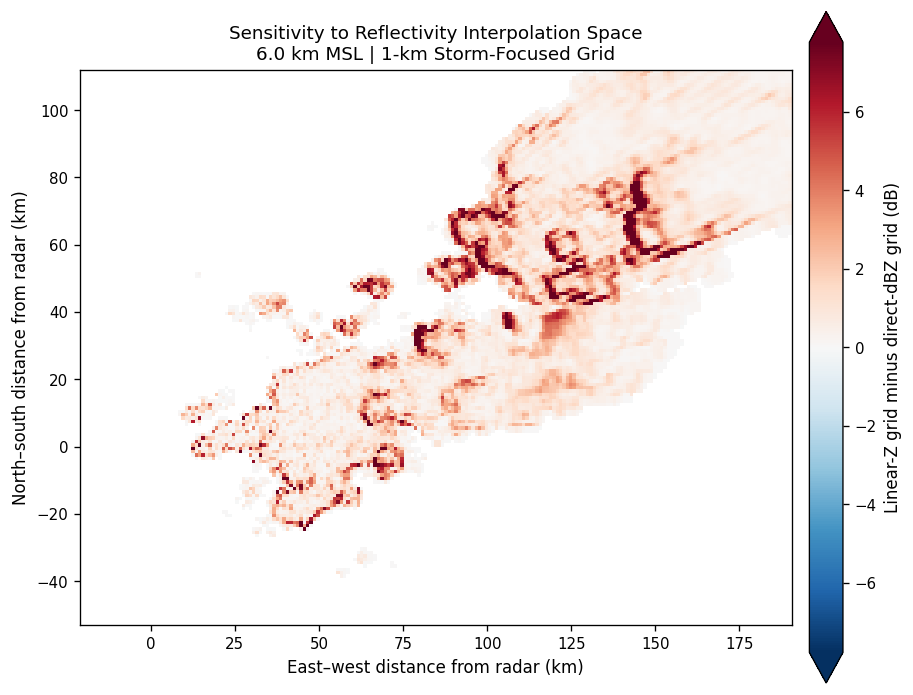

In [46]:
# CELL 46 — Interpolation-space difference figure

x_interp_km = (
    np.asarray(
        direct_grid.x[
            "data"
        ]
    )
    / 1000.0
)

y_interp_km = (
    np.asarray(
        direct_grid.y[
            "data"
        ]
    )
    / 1000.0
)

diff_values = (
    difference_db.compressed()
)

if diff_values.size:
    diff_limit = float(
        np.nanpercentile(
            np.abs(
                diff_values
            ),
            98,
        )
    )

    diff_limit = max(
        diff_limit,
        0.5,
    )
else:
    diff_limit = 1.0


fig = plt.figure(
    figsize=(
        7.5,
        6.3,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    x_interp_km,
    y_interp_km,
    difference_db,
    shading="auto",
    cmap="RdBu_r",
    vmin=(
        -diff_limit
    ),
    vmax=(
        diff_limit
    ),
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.90,
    extend="both",
)

cbar.set_label(
    "Linear-Z grid minus direct-dBZ grid (dB)"
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    (
        "Sensitivity to Reflectivity Interpolation Space\n"
        f"{EXPERIMENT_CAPPI_MSL_KM:.1f} km MSL | "
        "1-km Storm-Focused Grid"
    )
)

F = (
    FIGURE_DIR
    / "03_fig06_interpolation_space_difference.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="interpolation space sensitivity",
    height_km_MSL=(
        EXPERIMENT_CAPPI_MSL_KM
    ),
    processing=(
        "Linear-Z gridding converted back to dBZ minus direct dBZ gridding."
    ),
    units="dB",
    time_UTC=str(
        utc_time
    ),
)

plt.show()

# 25. CRS: radar-centered Cartesian → geographic → UTM

Py-ART Grid ใช้ local azimuthal-equidistant-like Cartesian representation รอบ radar origin

Workflow ทาง GIS:

```text
Radar-centered x/y
        ↓
Py-ART AEQD
        ↓
Longitude / Latitude
        ↓
EPSG:4326
        ↓
Automatic UTM zone
        ↓
Omkoi → UTM Zone 47N
        ↓
EPSG:32647
```

Notebook จะ derive UTM จาก radar longitude/latitude โดยอัตโนมัติ ไม่ hard-code zone

In [47]:
# CELL 47 — Inspect grid projection and derive UTM

projection_metadata = {
    "grid_projparams": str(
        full_grid.get_projparams()
    ),
    "origin_latitude_deg": float(
        full_grid.origin_latitude[
            "data"
        ][0]
    ),
    "origin_longitude_deg": float(
        full_grid.origin_longitude[
            "data"
        ][0]
    ),
    "origin_altitude_m_MSL": float(
        full_grid.origin_altitude[
            "data"
        ][0]
    ),
}

display(
    pd.DataFrame(
        projection_metadata.items(),
        columns=[
            "projection_property",
            "value",
        ],
    )
)


def utm_from_lon_lat(
    lon,
    lat,
):
    zone = int(
        np.floor(
            (
                lon
                + 180.0
            )
            / 6.0
        )
        + 1
    )

    if lat >= 0:
        epsg = (
            32600
            + zone
        )

        hemisphere = (
            "N"
        )

    else:
        epsg = (
            32700
            + zone
        )

        hemisphere = (
            "S"
        )

    return {
        "zone": (
            zone
        ),
        "hemisphere": (
            hemisphere
        ),
        "epsg": (
            epsg
        ),
        "crs": CRS.from_epsg(
            epsg
        ),
    }


UTM_INFO = (
    utm_from_lon_lat(
        radar_lon,
        radar_lat,
    )
)

print(
    "Automatic UTM:",
    f"{UTM_INFO['zone']}"
    f"{UTM_INFO['hemisphere']}",
)

print(
    "EPSG:",
    UTM_INFO[
        "epsg"
    ],
)

,projection_property,value
0,grid_projparams,"{'proj': 'pyart_aeqd', 'lon_0': np.float64(98...."
1,origin_latitude_deg,17.798207
2,origin_longitude_deg,98.432326
3,origin_altitude_m_MSL,0.0


Automatic UTM: 47N
EPSG: 32647


In [48]:
# CELL 48 — Coordinate round-trip test

to_utm = (
    Transformer.from_crs(
        "EPSG:4326",
        UTM_INFO[
            "crs"
        ],
        always_xy=True,
    )
)

to_wgs84 = (
    Transformer.from_crs(
        UTM_INFO[
            "crs"
        ],
        "EPSG:4326",
        always_xy=True,
    )
)

radar_easting, radar_northing = (
    to_utm.transform(
        radar_lon,
        radar_lat,
    )
)

lon_back, lat_back = (
    to_wgs84.transform(
        radar_easting,
        radar_northing,
    )
)

coordinate_roundtrip = pd.DataFrame({
    "quantity": [
        "radar_longitude_deg",
        "radar_latitude_deg",
        "UTM_easting_m",
        "UTM_northing_m",
        "roundtrip_longitude_deg",
        "roundtrip_latitude_deg",
        "longitude_roundtrip_error_deg",
        "latitude_roundtrip_error_deg",
    ],
    "value": [
        radar_lon,
        radar_lat,
        radar_easting,
        radar_northing,
        lon_back,
        lat_back,
        lon_back
        - radar_lon,
        lat_back
        - radar_lat,
    ],
})

display(
    coordinate_roundtrip
)

,quantity,value
0,radar_longitude_deg,9.843233e+01
1,radar_latitude_deg,1.779821e+01
2,UTM_easting_m,4.398358e+05
3,UTM_northing_m,1.967951e+06
4,roundtrip_longitude_deg,9.843233e+01
5,roundtrip_latitude_deg,1.779821e+01
6,longitude_roundtrip_error_deg,0.000000e+00
7,latitude_roundtrip_error_deg,0.000000e+00


# 26. Export peak 3-D grids เป็น NetCDF

จะบันทึกอย่างน้อย:

```text
full-domain 1-km 3-D grid
storm-focused 0.5-km 3-D grid
```

สองไฟล์นี้เป็น input หลักสำหรับ Notebook 06–08

NetCDF เก็บ:

- x/y/z coordinates
- projection metadata
- origin
- corrected reflectivity field
- mask

In [49]:
# CELL 49 — Save 3-D Grid NetCDF files

FULL_GRID_NETCDF = (
    OUTPUT_NETCDF_DIR
    / (
        "03_peak_full_domain_3D_ZH_"
        f"{utc_time.strftime('%Y%m%d_%H%M%S')}UTC.nc"
    )
)

STORM_GRID_NETCDF = (
    OUTPUT_NETCDF_DIR
    / (
        "03_peak_storm_focus_3D_ZH_"
        f"{utc_time.strftime('%Y%m%d_%H%M%S')}UTC.nc"
    )
)


full_grid.write(
    str(
        FULL_GRID_NETCDF
    )
)

storm_grid.write(
    str(
        STORM_GRID_NETCDF
    )
)

print(
    "Saved:",
    FULL_GRID_NETCDF,
)

print(
    f"Size: "
    f"{FULL_GRID_NETCDF.stat().st_size / 1024**2:.2f} MB"
)

print()

print(
    "Saved:",
    STORM_GRID_NETCDF,
)

print(
    f"Size: "
    f"{STORM_GRID_NETCDF.stat().st_size / 1024**2:.2f} MB"
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/netcdf/03_peak_full_domain_3D_ZH_20230318_111202UTC.nc
Size: 1.53 MB

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/netcdf/03_peak_storm_focus_3D_ZH_20230318_111202UTC.nc
Size: 3.44 MB


# 27. GeoTIFF export ของ selected CAPPI levels

Export ระดับ:

```text
2, 6, 10, 14 km MSL
```

เป็น:

1. native radar AEQD GeoTIFF
2. UTM GeoTIFF

สำหรับ UTM reprojection ใช้ **nearest-neighbor resampling** เป็นค่าเริ่มต้น เพื่อไม่เพิ่ม spatial smoothing รอบที่สองหลังจาก radar gridding

> **RESEARCH NOTE**
>
> GeoTIFF reprojection เป็น spatial transformation เพิ่มเติมจาก radar gridding  
> ควรรายงาน resampling method ใน Methods

In [50]:
# CELL 50 — Native AEQD raster geometry

PYART_SPHERE_RADIUS_M = (
    6370997.0
)

NATIVE_AEQD_CRS = CRS.from_proj4(
    (
        f"+proj=aeqd "
        f"+lat_0={radar_lat} "
        f"+lon_0={radar_lon} "
        f"+R={PYART_SPHERE_RADIUS_M} "
        "+units=m "
        "+no_defs"
    )
)

full_x_m = np.asarray(
    full_grid.x[
        "data"
    ],
    dtype=float,
)

full_y_m = np.asarray(
    full_grid.y[
        "data"
    ],
    dtype=float,
)

dx_m = float(
    np.nanmedian(
        np.diff(
            full_x_m
        )
    )
)

dy_m = float(
    np.nanmedian(
        np.diff(
            full_y_m
        )
    )
)

west = float(
    full_x_m.min()
    - dx_m
    / 2.0
)

north = float(
    full_y_m.max()
    + dy_m
    / 2.0
)

native_transform = (
    from_origin(
        west,
        north,
        dx_m,
        dy_m,
    )
)

print(
    "Native AEQD CRS:"
)

print(
    NATIVE_AEQD_CRS
)

print(
    "Pixel size:",
    f"{dx_m:.0f} × {dy_m:.0f} m",
)

Native AEQD CRS:
+proj=aeqd +lat_0=17.798207465277777 +lon_0=98.4323263888889 +R=6370997.0 +units=m +no_defs +type=crs
Pixel size: 1000 × 1000 m


In [51]:
# CELL 51 — GeoTIFF export helpers

def export_cappi_native_geotiff(
    grid_object,
    *,
    target_height_km,
    output_path,
):
    cappi = extract_cappi(
        grid_object,
        FIELD_Z,
        target_height_km,
    )

    data = np.ma.asarray(
        cappi[
            "data"
        ]
    )

    raster_array = np.flipud(
        data.filled(
            GEOTIFF_NODATA
        )
    ).astype(
        "float32"
    )

    output_path = Path(
        output_path
    )

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=raster_array.shape[
            0
        ],
        width=raster_array.shape[
            1
        ],
        count=1,
        dtype="float32",
        crs=(
            NATIVE_AEQD_CRS
        ),
        transform=(
            native_transform
        ),
        nodata=(
            GEOTIFF_NODATA
        ),
        compress="deflate",
    ) as dst:

        dst.write(
            raster_array,
            1,
        )

        dst.update_tags(
            radar_site=(
                site_name
            ),
            event_id=(
                ACTIVE_EVENT.get(
                    "event_id"
                )
            ),
            source_file=(
                selected_filename
            ),
            field=(
                FIELD_Z
            ),
            display_name=(
                "Corrected Reflectivity"
            ),
            units="dBZ",
            height_reference="MSL",
            height_km=(
                cappi[
                    "actual_height_km_MSL"
                ]
            ),
            observation_time_UTC=(
                str(
                    utc_time
                )
            ),
            gridding=(
                "Barnes2 + dist_beam"
            ),
        )

    return {
        "path": (
            output_path
        ),
        "height_km_MSL": (
            cappi[
                "actual_height_km_MSL"
            ]
        ),
    }


def reproject_geotiff_to_utm(
    native_path,
    utm_path,
):
    native_path = Path(
        native_path
    )

    utm_path = Path(
        utm_path
    )

    with rasterio.open(
        native_path
    ) as src:

        dst_transform, dst_width, dst_height = (
            calculate_default_transform(
                src.crs,
                UTM_INFO[
                    "crs"
                ],
                src.width,
                src.height,
                *src.bounds,
                resolution=(
                    FULL_DX_KM
                    * 1000.0
                ),
            )
        )

        profile = (
            src.profile.copy()
        )

        profile.update({
            "crs": (
                UTM_INFO[
                    "crs"
                ]
            ),
            "transform": (
                dst_transform
            ),
            "width": (
                dst_width
            ),
            "height": (
                dst_height
            ),
            "nodata": (
                GEOTIFF_NODATA
            ),
            "compress": (
                "deflate"
            ),
        })

        with rasterio.open(
            utm_path,
            "w",
            **profile
        ) as dst:

            reproject(
                source=(
                    rasterio.band(
                        src,
                        1,
                    )
                ),
                destination=(
                    rasterio.band(
                        dst,
                        1,
                    )
                ),
                src_transform=(
                    src.transform
                ),
                src_crs=(
                    src.crs
                ),
                src_nodata=(
                    GEOTIFF_NODATA
                ),
                dst_transform=(
                    dst_transform
                ),
                dst_crs=(
                    UTM_INFO[
                        "crs"
                    ]
                ),
                dst_nodata=(
                    GEOTIFF_NODATA
                ),
                resampling=(
                    Resampling.nearest
                ),
            )

            dst.update_tags(
                source_raster=(
                    native_path.name
                ),
                resampling=(
                    "nearest"
                ),
            )

    return (
        utm_path
    )

In [52]:
# CELL 52 — Export selected CAPPI GeoTIFFs

GEOTIFF_RECORDS = []

for target_height in (
    PRIMARY_CAPPI_LEVELS_MSL_KM
):
    native_path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "03_CAPPI_ZH_"
            f"{target_height:.1f}kmMSL_"
            "native_AEQD.tif"
        )
    )

    native_result = (
        export_cappi_native_geotiff(
            full_grid,
            target_height_km=(
                target_height
            ),
            output_path=(
                native_path
            ),
        )
    )

    utm_path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "03_CAPPI_ZH_"
            f"{target_height:.1f}kmMSL_"
            f"UTM{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}.tif"
        )
    )

    reproject_geotiff_to_utm(
        native_path,
        utm_path,
    )

    GEOTIFF_RECORDS.append({
        "requested_height_km_MSL": (
            target_height
        ),
        "actual_height_km_MSL": (
            native_result[
                "height_km_MSL"
            ]
        ),
        "native_AEQD_path": str(
            native_path
        ),
        "UTM_path": str(
            utm_path
        ),
        "UTM_EPSG": (
            UTM_INFO[
                "epsg"
            ]
        ),
        "reprojection_resampling": (
            "nearest"
        ),
    })


geotiff_manifest = pd.DataFrame(
    GEOTIFF_RECORDS
)

display(
    geotiff_manifest
)

GEOTIFF_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "03_GeoTIFF_manifest.csv"
)

geotiff_manifest.to_csv(
    GEOTIFF_MANIFEST_CSV,
    index=False,
)

,requested_height_km_MSL,actual_height_km_MSL,native_AEQD_path,UTM_path,UTM_EPSG,reprojection_resampling
0,2.0,2.0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,32647,nearest
1,6.0,6.0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,32647,nearest
2,10.0,10.0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,32647,nearest
3,14.0,14.0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,32647,nearest


In [53]:
# CELL 53 — Independent GeoTIFF validation

validation_rows = []

for _, record in (
    geotiff_manifest.iterrows()
):
    for raster_type, path_column in [
        (
            "native_AEQD",
            "native_AEQD_path",
        ),
        (
            "UTM",
            "UTM_path",
        ),
    ]:
        path = Path(
            record[
                path_column
            ]
        )

        with rasterio.open(
            path
        ) as src:

            data = src.read(
                1,
                masked=True,
            )

            validation_rows.append({
                "height_km_MSL": float(
                    record[
                        "actual_height_km_MSL"
                    ]
                ),
                "raster_type": (
                    raster_type
                ),
                "path": str(
                    path
                ),
                "crs": str(
                    src.crs
                ),
                "width": (
                    src.width
                ),
                "height": (
                    src.height
                ),
                "valid_pixel_count": int(
                    data.count()
                ),
                "min_dBZ": (
                    float(
                        data.min()
                    )
                    if data.count()
                    else np.nan
                ),
                "max_dBZ": (
                    float(
                        data.max()
                    )
                    if data.count()
                    else np.nan
                ),
                "nodata": (
                    src.nodata
                ),
            })


geotiff_validation = pd.DataFrame(
    validation_rows
)

display(
    geotiff_validation
)

GEOTIFF_VALIDATION_CSV = (
    OUTPUT_CSV_DIR
    / "03_GeoTIFF_validation.csv"
)

geotiff_validation.to_csv(
    GEOTIFF_VALIDATION_CSV,
    index=False,
)

,height_km_MSL,raster_type,path,crs,width,height,valid_pixel_count,min_dBZ,max_dBZ,nodata
0,2.0,native_AEQD,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",441,441,12379,-17.500000,65.983719,-9999.0
1,2.0,UTM,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,444,441,12329,-17.500000,65.983719,-9999.0
2,6.0,native_AEQD,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",441,441,18270,-15.499999,64.081779,-9999.0
3,6.0,UTM,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,444,441,18230,-15.499999,64.081779,-9999.0
4,10.0,native_AEQD,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",441,441,14985,-11.000000,55.879383,-9999.0
5,10.0,UTM,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,444,441,14928,-11.000000,55.879383,-9999.0
6,14.0,native_AEQD,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",441,441,4318,-7.000000,32.134773,-9999.0
7,14.0,UTM,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,444,441,4273,-7.000000,32.134773,-9999.0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/03/03_fig07_UTM_GeoTIFF_validation.png


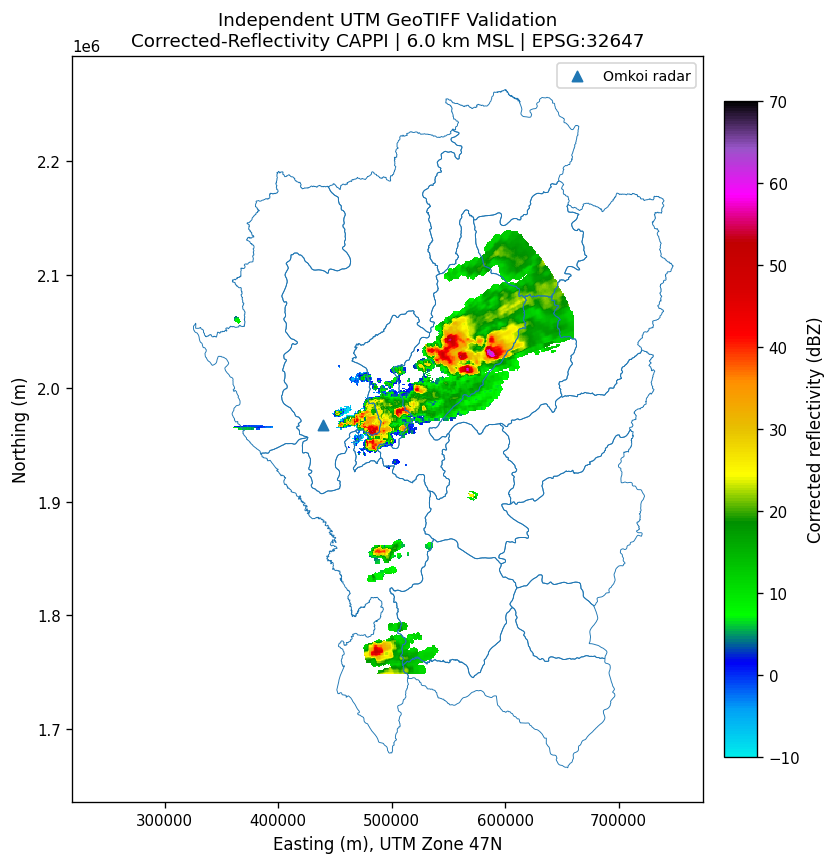

In [54]:
# CELL 54 — Independently reopen and plot the 6-km UTM GeoTIFF

validation_height = (
    EXPERIMENT_CAPPI_MSL_KM
)

utm_row = (
    geotiff_manifest.loc[
        np.isclose(
            geotiff_manifest[
                "actual_height_km_MSL"
            ],
            validation_height,
        )
    ]
)

if utm_row.empty:
    raise RuntimeError(
        "ไม่พบ 6-km UTM GeoTIFF สำหรับ validation figure"
    )

UTM_VALIDATION_PATH = Path(
    utm_row.iloc[
        0
    ][
        "UTM_path"
    ]
)

with rasterio.open(
    UTM_VALIDATION_PATH
) as src:
    utm_data = src.read(
        1,
        masked=True,
    )

    bounds = src.bounds

    utm_crs = src.crs


adm1_utm = adm1_clip.to_crs(
    utm_crs
)

fig = plt.figure(
    figsize=(
        8.1,
        7.1,
    )
)

ax = fig.add_subplot(
    111
)

image = ax.imshow(
    utm_data,
    extent=[
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top,
    ],
    origin="upper",
    cmap=CMAP_Z,
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
    interpolation="nearest",
)

adm1_utm.boundary.plot(
    ax=ax,
    linewidth=0.55,
)

ax.scatter(
    radar_easting,
    radar_northing,
    marker="^",
    s=38,
    label="Omkoi radar",
)

cbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.025,
    shrink=0.88,
)

cbar.set_label(
    "Corrected reflectivity (dBZ)"
)

ax.set_xlabel(
    (
        "Easting (m), UTM Zone "
        f"{UTM_INFO['zone']}"
        f"{UTM_INFO['hemisphere']}"
    )
)

ax.set_ylabel(
    "Northing (m)"
)

ax.set_title(
    (
        "Independent UTM GeoTIFF Validation\n"
        f"Corrected-Reflectivity CAPPI | "
        f"{validation_height:.1f} km MSL | "
        f"EPSG:{UTM_INFO['epsg']}"
    )
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "03_fig07_UTM_GeoTIFF_validation.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="GeoTIFF validation",
    height_km_MSL=(
        validation_height
    ),
    field=FIELD_Z,
    processing=(
        "Independent Rasterio reopen of nearest-neighbor UTM reprojection."
    ),
    units="dBZ",
    time_UTC=str(
        utc_time
    ),
    colormap=CMAP_Z,
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
)

plt.show()

# 28. ADVANCED — สร้าง event-focused 3-D grids สำหรับ 10 volumes

สำหรับ Notebook 07 การวิเคราะห์ severe-core evolution จะได้ประโยชน์จาก 3-D grids หลายเวลา

แต่การ grid 10 volumes สามมิติใช้เวลามากกว่า peak-volume workflow

จึงกำหนด:

```python
RUN_EVENT_BATCH_GRIDDING = False
```

เป็นค่าเริ่มต้น

หากต้องการสร้าง archive ก่อน Notebook 07 ให้เปลี่ยนเป็น `True` แล้ว Run cell นี้ใหม่

Batch grid ใช้:

```text
storm-focused domain
1-km horizontal spacing
1.5–20 km MSL
0.5-km vertical spacing
```

In [55]:
# CELL 55 — Optional 10-volume event-grid archive

batch_rows = []

batch_xmin_km = align_down(
    storm_xmin_km,
    EVENT_BATCH_DX_KM,
)

batch_xmax_km = align_up(
    storm_xmax_km,
    EVENT_BATCH_DX_KM,
)

batch_ymin_km = align_down(
    storm_ymin_km,
    EVENT_BATCH_DY_KM,
)

batch_ymax_km = align_up(
    storm_ymax_km,
    EVENT_BATCH_DY_KM,
)

BATCH_NX = count_axis_points(
    batch_xmin_km,
    batch_xmax_km,
    EVENT_BATCH_DX_KM,
)

BATCH_NY = count_axis_points(
    batch_ymin_km,
    batch_ymax_km,
    EVENT_BATCH_DY_KM,
)

BATCH_GRID_SHAPE = (
    FULL_NZ,
    BATCH_NY,
    BATCH_NX,
)

BATCH_GRID_LIMITS = (
    (
        GRID_Z_MIN_MSL_KM
        * 1000.0,
        GRID_Z_MAX_MSL_KM
        * 1000.0,
    ),
    (
        batch_ymin_km
        * 1000.0,
        batch_ymax_km
        * 1000.0,
    ),
    (
        batch_xmin_km
        * 1000.0,
        batch_xmax_km
        * 1000.0,
    ),
)


if RUN_EVENT_BATCH_GRIDDING:

    for index, filename in enumerate(
        RADAR_FILES,
        start=1,
    ):
        print(
            f"[{index:02d}/{len(RADAR_FILES)}] "
            f"{filename}"
        )

        radar_i = read_radar_file(
            RADAR_DIR
            / filename
        )

        utc_i = radar_datetime_utc(
            radar_i
        )

        grid_i, elapsed_i = (
            build_3d_reflectivity_grid(
                radar_i,
                grid_shape=(
                    BATCH_GRID_SHAPE
                ),
                grid_limits=(
                    BATCH_GRID_LIMITS
                ),
                min_radius_m=(
                    MIN_RADIUS_M
                ),
            )
        )

        output_path = (
            OUTPUT_NETCDF_DIR
            / (
                "03_event_storm_3D_ZH_"
                f"{utc_i.strftime('%Y%m%d_%H%M%S')}UTC.nc"
            )
        )

        grid_i.write(
            str(
                output_path
            )
        )

        field_i = np.ma.asarray(
            grid_i.fields[
                FIELD_Z
            ][
                "data"
            ]
        )

        values_i = (
            field_i.compressed()
        )

        batch_rows.append({
            "filename": (
                filename
            ),
            "time_UTC": (
                utc_i
            ),
            "status": (
                "CREATED"
            ),
            "grid_path": str(
                output_path
            ),
            "grid_nz": (
                BATCH_GRID_SHAPE[
                    0
                ]
            ),
            "grid_ny": (
                BATCH_GRID_SHAPE[
                    1
                ]
            ),
            "grid_nx": (
                BATCH_GRID_SHAPE[
                    2
                ]
            ),
            "dx_km": (
                EVENT_BATCH_DX_KM
            ),
            "dy_km": (
                EVENT_BATCH_DY_KM
            ),
            "dz_km": (
                GRID_DZ_KM
            ),
            "max_ZH_dBZ": (
                float(
                    np.nanmax(
                        values_i
                    )
                )
                if values_i.size
                else np.nan
            ),
            "elapsed_seconds": (
                elapsed_i
            ),
            "file_size_MB": (
                output_path.stat().st_size
                / 1024**2
            ),
        })

        del radar_i
        del grid_i
        gc.collect()

else:
    batch_rows.append({
        "filename": (
            None
        ),
        "time_UTC": (
            None
        ),
        "status": (
            "SKIPPED"
        ),
        "grid_path": (
            None
        ),
        "grid_nz": (
            BATCH_GRID_SHAPE[
                0
            ]
        ),
        "grid_ny": (
            BATCH_GRID_SHAPE[
                1
            ]
        ),
        "grid_nx": (
            BATCH_GRID_SHAPE[
                2
            ]
        ),
        "dx_km": (
            EVENT_BATCH_DX_KM
        ),
        "dy_km": (
            EVENT_BATCH_DY_KM
        ),
        "dz_km": (
            GRID_DZ_KM
        ),
        "max_ZH_dBZ": (
            np.nan
        ),
        "elapsed_seconds": (
            np.nan
        ),
        "file_size_MB": (
            np.nan
        ),
    })


event_grid_manifest = pd.DataFrame(
    batch_rows
)

display(
    event_grid_manifest
)

EVENT_GRID_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "03_event_3D_grid_manifest.csv"
)

event_grid_manifest.to_csv(
    EVENT_GRID_MANIFEST_CSV,
    index=False,
)

,filename,time_UTC,status,grid_path,grid_nz,grid_ny,grid_nx,dx_km,dy_km,dz_km,max_ZH_dBZ,elapsed_seconds,file_size_MB
0,None,None,SKIPPED,None,38,166,212,1.0,1.0,0.5,NaN,NaN,NaN


# 29. Export grid configuration และ Methods metadata

เพื่อให้ code สามารถนำไปใช้ในงานวิจัยได้ ต้องสามารถตอบคำถามได้ว่า:

```text
ใช้ radar file ใด?
เวลาใด?
ใช้ field ใด?
grid spacing เท่าใด?
vertical reference คืออะไร?
ROI แบบใด?
weighting แบบใด?
storm ROI มาจากไหน?
CAPPI ระดับใด?
ใช้ CRS อะไร?
GeoTIFF resample อย่างไร?
```

จึง export parameter tables แยกจาก figure

In [56]:
# CELL 56 — Grid configuration table

grid_configuration = pd.DataFrame({
    "parameter": [
        "event_id",
        "event_type",
        "source_file",
        "observation_time_UTC",
        "radar_site",
        "radar_band",
        "radar_latitude_deg",
        "radar_longitude_deg",
        "radar_altitude_m_MSL",
        "field",
        "strong_echo_sector",
        "strong_echo_reference_azimuth_deg",
        "strong_echo_reference_range_km",
        "full_grid_nz",
        "full_grid_ny",
        "full_grid_nx",
        "full_grid_dx_km",
        "full_grid_dy_km",
        "full_grid_dz_km",
        "full_grid_z_min_km_MSL",
        "full_grid_z_max_km_MSL",
        "full_grid_half_width_km",
        "storm_grid_nz",
        "storm_grid_ny",
        "storm_grid_nx",
        "storm_grid_dx_km",
        "storm_grid_dy_km",
        "storm_grid_dz_km",
        "storm_grid_xmin_km",
        "storm_grid_xmax_km",
        "storm_grid_ymin_km",
        "storm_grid_ymax_km",
        "weighting_function",
        "roi_function",
        "minimum_roi_m",
        "roi_nb",
        "roi_bsp",
        "roi_h_factor",
        "grid_origin_altitude_m_MSL",
        "UTM_zone",
        "UTM_EPSG",
        "full_grid_elapsed_s",
        "storm_grid_elapsed_s",
        "full_grid_NetCDF",
        "storm_grid_NetCDF",
        "event_batch_enabled",
    ],
    "value": [
        ACTIVE_EVENT.get(
            "event_id"
        ),
        ACTIVE_EVENT.get(
            "event_type"
        ),
        selected_filename,
        str(
            utc_time
        ),
        site_name,
        COURSE_CONFIG[
            "radar"
        ].get(
            "band"
        ),
        radar_lat,
        radar_lon,
        radar_alt_msl_m,
        FIELD_Z,
        DOMINANT_CORE_SECTOR,
        MEDIAN_CORE_AZIMUTH_DEG,
        MEDIAN_CORE_RANGE_KM,
        FULL_NZ,
        FULL_NY,
        FULL_NX,
        FULL_DX_KM,
        FULL_DY_KM,
        GRID_DZ_KM,
        GRID_Z_MIN_MSL_KM,
        GRID_Z_MAX_MSL_KM,
        FULL_HALF_WIDTH_KM,
        STORM_NZ,
        STORM_NY,
        STORM_NX,
        STORM_DX_KM,
        STORM_DY_KM,
        GRID_DZ_KM,
        storm_xmin_km,
        storm_xmax_km,
        storm_ymin_km,
        storm_ymax_km,
        WEIGHTING_FUNCTION,
        ROI_FUNCTION,
        MIN_RADIUS_M,
        ROI_NB,
        ROI_BSP,
        str(
            ROI_H_FACTOR
        ),
        0.0,
        (
            f"{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}"
        ),
        UTM_INFO[
            "epsg"
        ],
        full_grid_elapsed_s,
        storm_grid_elapsed_s,
        str(
            FULL_GRID_NETCDF
        ),
        str(
            STORM_GRID_NETCDF
        ),
        RUN_EVENT_BATCH_GRIDDING,
    ],
})

display(
    grid_configuration
)

GRID_CONFIGURATION_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_configuration.csv"
)

grid_configuration.to_csv(
    GRID_CONFIGURATION_CSV,
    index=False,
)

print(
    "Saved:",
    GRID_CONFIGURATION_CSV,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,source_file,20230318111202.uf.gz
3,observation_time_UTC,2023-03-18 11:12:02+00:00
4,radar_site,Omkoi
5,radar_band,S
6,radar_latitude_deg,17.798207
7,radar_longitude_deg,98.432326
8,radar_altitude_m_MSL,1173.0
9,field,corrected_reflectivity


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/03_grid_configuration.csv


In [57]:
# CELL 57 — Processing metadata

processing_metadata = pd.DataFrame({
    "parameter": [
        "Cartesian_representation",
        "vertical_reference",
        "CAPPI_levels_km_MSL",
        "primary_GeoTIFF_levels_km_MSL",
        "core_reflectivity_thresholds_dBZ",
        "full_grid_horizontal_spacing_km",
        "storm_grid_horizontal_spacing_km",
        "vertical_grid_spacing_km",
        "weighting_function",
        "roi_function",
        "minimum_radius_m",
        "GeoTIFF_native_CRS",
        "GeoTIFF_target_UTM",
        "GeoTIFF_reprojection_resampling",
        "grid_spacing_interpretation",
        "CAPPI_interpretation",
        "column_max_interpretation",
        "interpolation_space_note",
    ],
    "value": [
        (
            "Py-ART map_gates_to_grid Cartesian interpolation"
        ),
        (
            "MSL; grid_origin_alt = 0 m"
        ),
        str(
            CAPPI_LEVELS_MSL_KM
        ),
        str(
            PRIMARY_CAPPI_LEVELS_MSL_KM
        ),
        str(
            CORE_THRESHOLDS_DBZ
        ),
        FULL_DX_KM,
        STORM_DX_KM,
        GRID_DZ_KM,
        WEIGHTING_FUNCTION,
        ROI_FUNCTION,
        MIN_RADIUS_M,
        str(
            NATIVE_AEQD_CRS
        ),
        (
            f"UTM Zone {UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']} "
            f"(EPSG:{UTM_INFO['epsg']})"
        ),
        (
            "nearest"
        ),
        (
            "Grid spacing is representation spacing, "
            "not independent observational resolution."
        ),
        (
            "CAPPI is an interpolated constant-MSL surface; "
            "sampling support varies with range and elevation."
        ),
        (
            "Column maximum is a vertical projection, "
            "not an echo-top or hail-probability product."
        ),
        (
            "Direct-dBZ and linear-Z gridding are compared as "
            "a methodological sensitivity experiment."
        ),
    ],
})

display(
    processing_metadata
)

PROCESSING_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "03_processing_metadata.csv"
)

processing_metadata.to_csv(
    PROCESSING_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    PROCESSING_METADATA_CSV,
)

,parameter,value
0,Cartesian_representation,Py-ART map_gates_to_grid Cartesian interpolation
1,vertical_reference,MSL; grid_origin_alt = 0 m
2,CAPPI_levels_km_MSL,"[2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 1..."
3,primary_GeoTIFF_levels_km_MSL,"[2.0, 6.0, 10.0, 14.0]"
4,core_reflectivity_thresholds_dBZ,"[40.0, 50.0, 55.0, 60.0]"
5,full_grid_horizontal_spacing_km,1.0
6,storm_grid_horizontal_spacing_km,0.5
7,vertical_grid_spacing_km,0.5
8,weighting_function,Barnes2
9,roi_function,dist_beam


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/03_processing_metadata.csv


# 30. Export figure manifest

In [58]:
# CELL 58 — Figure manifest

figure_manifest = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "03_figure_manifest.csv"
)

figure_manifest.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    figure_manifest
)

print(
    "Saved:",
    FIGURE_MANIFEST_CSV,
)

,figure_name,figure_path,source_file,product,processing,units,time_UTC,dpi,height_km_MSL,field,colormap,vmin,vmax
0,03_fig01_native_beam_sampling_at_core_range.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,native beam sampling,4/3-Earth-radius beam-center approximation.,km MSL,2023-03-18 11:12:02+00:00,300,NaN,NaN,NaN,NaN,NaN
1,03_fig02_vertical_data_support.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,vertical data support,Valid-grid fraction by constant MSL level.,fraction,2023-03-18 11:12:02+00:00,300,NaN,NaN,NaN,NaN,NaN
2,03_fig03_strong_echo_area_vs_height.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,strong echo area versus height,Area calculated on 1-km Cartesian grid; not an...,km2,2023-03-18 11:12:02+00:00,300,NaN,NaN,NaN,NaN,NaN
3,03_full_CAPPI_ZH_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,full-domain CAPPI,1-km full-domain Cartesian grid; Barnes2 + dis...,dBZ,2023-03-18 11:12:02+00:00,300,2.0,corrected_reflectivity,NWSRef,-10.0,70.0
4,03_full_CAPPI_ZH_6.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,full-domain CAPPI,1-km full-domain Cartesian grid; Barnes2 + dis...,dBZ,2023-03-18 11:12:02+00:00,300,6.0,corrected_reflectivity,NWSRef,-10.0,70.0
5,03_full_CAPPI_ZH_10.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,full-domain CAPPI,1-km full-domain Cartesian grid; Barnes2 + dis...,dBZ,2023-03-18 11:12:02+00:00,300,10.0,corrected_reflectivity,NWSRef,-10.0,70.0
6,03_full_CAPPI_ZH_14.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,full-domain CAPPI,1-km full-domain Cartesian grid; Barnes2 + dis...,dBZ,2023-03-18 11:12:02+00:00,300,14.0,corrected_reflectivity,NWSRef,-10.0,70.0
7,03_storm_CAPPI_ZH_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,storm-focused CAPPI,Storm-focused subset of 1-km full-domain grid;...,dBZ,2023-03-18 11:12:02+00:00,300,2.0,corrected_reflectivity,NWSRef,-10.0,70.0
8,03_storm_CAPPI_ZH_4.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,storm-focused CAPPI,Storm-focused subset of 1-km full-domain grid;...,dBZ,2023-03-18 11:12:02+00:00,300,4.0,corrected_reflectivity,NWSRef,-10.0,70.0
9,03_storm_CAPPI_ZH_6.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,storm-focused CAPPI,Storm-focused subset of 1-km full-domain grid;...,dBZ,2023-03-18 11:12:02+00:00,300,6.0,corrected_reflectivity,NWSRef,-10.0,70.0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/03_figure_manifest.csv


# 31. แนวทางเขียน Methods จาก Notebook นี้

ไม่ควรเขียน Methods จากความจำ

ให้ดึงค่าจริงจาก:

```text
03_grid_configuration.csv
03_processing_metadata.csv
03_core_range_beam_sampling.csv
03_CAPPI_nearest_beam_sampling.csv
```

ตัวอย่างข้อความ:

> The peak observed-hail radar volume was interpolated from its native polar geometry to a three-dimensional Cartesian grid using Py-ART's `map_gates_to_grid` algorithm. Corrected reflectivity was mapped using Barnes2 weighting and a distance-and-beam-dependent radius of influence. The full-domain grid used 1-km horizontal spacing over a ±220-km radar-centered domain, while the vertical coordinate extended from 1.5 to 20 km MSL at 0.5-km intervals. A storm-focused 0.5-km grid was additionally produced using the intense-echo region identified in the preceding PPI analysis. Constant-altitude reflectivity products were extracted between 2 and 18 km MSL. Spatial outputs were retained in the native radar-centered AEQD representation and additionally exported to UTM Zone 47N using nearest-neighbor reprojection.

ก่อนใช้จริงใน manuscript ต้องตรวจตัวเลขจาก CSV และปรับถ้อยคำให้ตรงกับ experiment ที่ใช้ในงานนั้น

# 32. CORE — แบบฝึกหัดสำหรับปริญญาตรี

### แบบฝึกหัด 1 — Beam sampling

จาก `03_core_range_beam_sampling.csv`:

- lowest sweep ที่ strong-echo range อยู่สูงกี่ km MSL?
- sweep ใดใกล้ 6 km MSL มากที่สุด?
- sweep ใดใกล้ 10 km MSL มากที่สุด?

### แบบฝึกหัด 2 — PPI vs CAPPI

อธิบายด้วยภาษาของตนเองว่า:

```text
0.5° PPI
```

ต่างจาก:

```text
2-km MSL CAPPI
```

อย่างไร

### แบบฝึกหัด 3 — Vertical support

ใช้ `03_peak_grid_vertical_support.csv` หา:

- ระดับที่ valid fraction สูงที่สุด
- ระดับที่ maximum ZH ยังเกิน 50 dBZ
- ระดับที่ strong-echo area ลดลงอย่างชัดเจน

ห้ามเรียกระดับสุดท้ายว่า echo top ในบทนี้

### แบบฝึกหัด 4 — Cartesian area

อธิบายว่าเหตุใดใน Notebook 03 จึงเริ่มรายงาน `km²` ได้ แต่ Notebook 02 ใช้เพียง `number of radar gates`

# 33. ADVANCED / MSc — แบบฝึกหัด

### แบบฝึกหัด 5 — Grid-spacing sensitivity

ใช้ `03_grid_resolution_experiment.csv` เปรียบเทียบ:

```text
2 km
1 km
0.5 km
```

สำหรับ:

- processing time
- maximum ZH
- P95 ZH
- area ≥ 50 dBZ

อภิปรายว่า grid ละเอียดขึ้นหมายถึงข้อมูลจริงละเอียดขึ้นหรือไม่

### แบบฝึกหัด 6 — ROI sensitivity

เปรียบเทียบ minimum ROI:

```text
500
1000
1500 m
```

อภิปราย trade-off ระหว่าง:

```text
coverage
smoothing
local maxima
```

### แบบฝึกหัด 7 — CAPPI sampling mismatch

เลือก CAPPI 2, 6, 10, 14 และ 18 km

รายงาน:

- nearest native elevation
- nearest beam-center height
- vertical mismatch

อภิปรายว่าระดับใดควรตีความระมัดระวังที่สุด

### แบบฝึกหัด 8 — CRS

อธิบาย chain:

```text
Radar x/y → geographic → UTM
```

และอธิบายว่าทำไม Omkoi อยู่ UTM Zone 47N

# 34. RESEARCH — แบบฝึกหัดสำหรับงานวิจัย

### แบบฝึกหัด 9 — Interpolation space

ใช้ `03_interpolation_space_experiment.csv`

เปรียบเทียบ:

```text
Direct dBZ gridding
vs
Linear-Z gridding → dBZ
```

อภิปรายว่าความแตกต่างเกิดจากอะไร และควรรายงาน method อย่างไร

### แบบฝึกหัด 10 — Publication figure

เลือก CAPPI 6 หรือ 10 km MSL แล้วเขียน figure caption ที่ระบุ:

- radar site
- event
- UTC time
- CAPPI height
- corrected reflectivity
- Cartesian spacing
- interpolation method
- GIS boundaries
- ข้อจำกัดว่า CAPPI เป็น interpolated product

### แบบฝึกหัด 11 — Severe-storm bridge

จาก vertical-support table เสนอว่าควรวิเคราะห์ vertical cross section ผ่าน storm ใน azimuth ใด

ใช้ข้อมูลจาก Notebook 02:

```text
median core azimuth ≈ 74°
dominant sector = ENE
```

แต่ยังไม่สร้าง cross section ใน Notebook 03

# 35. RESEARCH NOTE — สิ่งที่ยังไม่ควรสรุปจาก Notebook 03

Notebook นี้สามารถสรุปได้ว่า:

- storm มี Cartesian representation อย่างไร
- strong reflectivity ปรากฏใน CAPPI ระดับใด
- strong-echo area เปลี่ยนตามระดับอย่างไร
- sampling support เปลี่ยนตามระดับอย่างไร
- grid/ROI choices มีผลต่อ representation เท่าใด

แต่ยังไม่ควรสรุปว่า:

```text
ระดับสุดท้ายของ ≥40 dBZ = official ET40
ระดับสุดท้ายของ ≥50 dBZ = hail top
column maximum = hail probability
60 dBZ = hail at surface
fine grid = fine observation
```

Echo-top definition, vertical cross section, VIL/VILD และ hail retrieval จะถูกสอนใน Notebook 06–08

# 36. Final readiness check

In [59]:
# CELL 59 — Notebook 03 readiness

checks = []


def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": (
            item
        ),
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": (
            note
        ),
    })


add_check(
    "Notebook 01 event readiness",
    bool(
        SETUP_STATUS_01.get(
            "ready",
            False,
        )
    ),
)

add_check(
    "Notebook 02 readiness",
    bool(
        (
            readiness_02[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Active event is observed hail",
    ACTIVE_EVENT.get(
        "event_type"
    )
    == "observed_hail",
)

add_check(
    "Peak representative radar readable",
    radar
    is not None,
)

add_check(
    "Corrected reflectivity available",
    FIELD_Z
    in radar.fields,
)

add_check(
    "Fourteen native elevation sweeps available",
    int(
        radar.nsweeps
    )
    == 14,
)

add_check(
    "Full-domain 3-D Cartesian grid created",
    full_grid
    is not None,
)

add_check(
    "Full grid shape matches design",
    tuple(
        full_grid.fields[
            FIELD_Z
        ][
            "data"
        ].shape
    )
    == FULL_GRID_SHAPE,
)

add_check(
    "Full grid vertical coordinate is MSL",
    np.isclose(
        float(
            full_grid.origin_altitude[
                "data"
            ][0]
        ),
        0.0,
    ),
)

add_check(
    "Storm-focused 0.5-km 3-D grid created",
    storm_grid
    is not None,
)

add_check(
    "Storm-grid shape matches design",
    tuple(
        storm_grid.fields[
            FIELD_Z
        ][
            "data"
        ].shape
    )
    == STORM_GRID_SHAPE,
)

add_check(
    "Beam-sampling table exported",
    CORE_BEAM_CSV.exists(),
)

add_check(
    "CAPPI nearest-beam table exported",
    CAPPI_BEAM_MATCH_CSV.exists(),
)

add_check(
    "Vertical support exported",
    VERTICAL_SUPPORT_CSV.exists(),
)

add_check(
    "Storm-grid support exported",
    STORM_SUPPORT_CSV.exists(),
)

add_check(
    "CAPPI summary exported",
    CAPPI_LEVEL_CSV.exists(),
)

add_check(
    "Grid-spacing experiment exported",
    GRID_SPACING_CSV.exists(),
)

add_check(
    "ROI sensitivity exported",
    ROI_SENSITIVITY_CSV.exists(),
)

add_check(
    "Interpolation-space experiment exported",
    INTERPOLATION_SPACE_CSV.exists(),
)

add_check(
    "Automatic UTM CRS derived",
    UTM_INFO[
        "epsg"
    ]
    > 0,
    (
        f"EPSG:{UTM_INFO['epsg']}"
    ),
)

add_check(
    "Selected CAPPI GeoTIFFs exported",
    (
        len(
            geotiff_manifest
        )
        == len(
            PRIMARY_CAPPI_LEVELS_MSL_KM
        )
        and all(
            Path(
                path
            ).exists()
            for path in (
                geotiff_manifest[
                    "UTM_path"
                ]
            )
        )
    ),
)

add_check(
    "GeoTIFF validation exported",
    GEOTIFF_VALIDATION_CSV.exists(),
)

add_check(
    "Full-domain 3-D NetCDF created",
    FULL_GRID_NETCDF.exists(),
)

add_check(
    "Storm-focused 3-D NetCDF created",
    STORM_GRID_NETCDF.exists(),
)

add_check(
    "Event-grid manifest exported",
    EVENT_GRID_MANIFEST_CSV.exists(),
    (
        "Batch archive is optional; "
        f"RUN_EVENT_BATCH_GRIDDING={RUN_EVENT_BATCH_GRIDDING}"
    ),
)

add_check(
    "Grid configuration exported",
    GRID_CONFIGURATION_CSV.exists(),
)

add_check(
    "Processing metadata exported",
    PROCESSING_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)


readiness_03 = pd.DataFrame(
    checks
)

display(
    readiness_03
)

NOTEBOOK_03_READY = bool(
    (
        readiness_03[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_readiness_check.csv"
)

readiness_03.to_csv(
    READINESS_03_CSV,
    index=False,
)

print()

print(
    (
        "NOTEBOOK 03 READY FOR "
        "VERTICAL STORM-STRUCTURE AND ECHO-TOP ANALYSIS"
    )
    if NOTEBOOK_03_READY
    else "NOTEBOOK 03 REQUIRES REVIEW"
)

,item,status,note
0,Notebook 01 event readiness,PASS,
1,Notebook 02 readiness,PASS,
2,Active event is observed hail,PASS,
3,Peak representative radar readable,PASS,
4,Corrected reflectivity available,PASS,
5,Fourteen native elevation sweeps available,PASS,
6,Full-domain 3-D Cartesian grid created,PASS,
7,Full grid shape matches design,PASS,
8,Full grid vertical coordinate is MSL,PASS,
9,Storm-focused 0.5-km 3-D grid created,PASS,



NOTEBOOK 03 READY FOR VERTICAL STORM-STRUCTURE AND ECHO-TOP ANALYSIS


# ข้อความสำคัญที่ต้องจำ

1. **Cartesian grid เป็น interpolated representation**
2. `PPI ≠ CAPPI`
3. CAPPI เป็นระดับความสูงคงที่ แต่ radar sampling ที่รองรับระดับนั้นเปลี่ยนตาม range
4. CAPPI 2 km MSL ไม่ใช่ direct observation ที่ 2 km ทุกตำแหน่ง
5. Grid spacing ไม่เท่ากับ observational resolution
6. 0.5-km grid ไม่ได้สร้างข้อมูลใหม่ระหว่าง radar beams
7. Vertical grid spacing 0.5 km ไม่ได้หมายถึงมี radar observation ทุก 0.5 km
8. Full-domain grid และ storm-focused grid ตอบโจทย์ต่างกัน
9. Radius of Influence และ weighting function มีผลต่อ storm representation
10. dBZ เป็น logarithmic quantity และ interpolation space เป็น methodological choice
11. Cartesian grid ทำให้เริ่มคำนวณ horizontal echo area เป็น km² ได้
12. Column maximum ไม่ใช่ CAPPI
13. Column maximum ไม่ใช่ echo top
14. Strong reflectivity ไม่ใช่ pixel-level hail confirmation
15. MSL, ARL และ AGL ต้องแยกให้ชัด
16. CRS transformation เป็นส่วนหนึ่งของ scientific reproducibility
17. GeoTIFF reprojection เป็น processing step เพิ่มเติม
18. Notebook 06 จะนำ 3-D grids นี้ไปวิเคราะห์ vertical storm structure และ echo-top concepts

# Expected outputs

```text
event-specific 03_output/csv/
├── 03_core_range_beam_sampling.csv
├── 03_CAPPI_nearest_beam_sampling.csv
├── 03_polar_sampling_geometry.csv
├── 03_peak_grid_vertical_support.csv
├── 03_storm_focus_grid_vertical_support.csv
├── 03_CAPPI_level_summary.csv
├── 03_grid_resolution_experiment.csv
├── 03_ROI_sensitivity_experiment.csv
├── 03_interpolation_space_experiment.csv
├── 03_GeoTIFF_manifest.csv
├── 03_GeoTIFF_validation.csv
├── 03_event_3D_grid_manifest.csv
├── 03_grid_configuration.csv
├── 03_processing_metadata.csv
├── 03_figure_manifest.csv
└── 03_readiness_check.csv
```

```text
event-specific 03_output/netcdf/
├── 03_peak_full_domain_3D_ZH_YYYYMMDD_HHMMSSUTC.nc
└── 03_peak_storm_focus_3D_ZH_YYYYMMDD_HHMMSSUTC.nc
```

หากเปิด `RUN_EVENT_BATCH_GRIDDING=True`:

```text
03_event_storm_3D_ZH_*.nc
```

```text
event-specific 03_output/geotiff/
├── 03_CAPPI_ZH_2.0kmMSL_native_AEQD.tif
├── 03_CAPPI_ZH_2.0kmMSL_UTM47N.tif
├── 03_CAPPI_ZH_6.0kmMSL_native_AEQD.tif
├── 03_CAPPI_ZH_6.0kmMSL_UTM47N.tif
├── 03_CAPPI_ZH_10.0kmMSL_native_AEQD.tif
├── 03_CAPPI_ZH_10.0kmMSL_UTM47N.tif
├── 03_CAPPI_ZH_14.0kmMSL_native_AEQD.tif
└── 03_CAPPI_ZH_14.0kmMSL_UTM47N.tif
```

เมื่อ cell สุดท้ายแสดง:

```text
NOTEBOOK 03 READY FOR VERTICAL STORM-STRUCTURE AND ECHO-TOP ANALYSIS
```

จึงเข้าสู่:

**Notebook 06 — Vertical Storm Structure, Cross Sections and Echo-Top Concepts**

# Technical references

เอกสารที่ควรอ่านประกอบ:

- Py-ART `grid_from_radars()` และ `map_gates_to_grid`
- Py-ART `Grid` object และ Cartesian projection
- Barnes objective analysis / radar gridding concepts
- Cartopy / GeoPandas / PyProj สำหรับ coordinate transformation
- Rasterio สำหรับ GeoTIFF
- Radar beam propagation ภายใต้ standard 4/3-Earth-radius approximation

> Notebook นี้ตั้งใจให้ผู้เรียนสามารถนำ workflow ไปต่อยอดงาน conference/journal ได้  
> แต่ parameter choices ต้องได้รับการตรวจสอบใหม่ทุกครั้งเมื่อเปลี่ยน radar, scan strategy, event หรือ scientific objective